# 🔧 Day 25: GPU FinOps & Cost Optimization - Hands-on Lab

This notebook connects to a local Docker Compose cluster (via ngrok/cloudflared tunnel) to demonstrate:
1. **GPU Cluster Monitoring** - Real-time GPU metrics
2. **Cost Tracking (OpenCost-like)** - Per-node cost allocation & waste analysis
3. **Spot Instance Management** - Bidding, preemption, savings
4. **Autoscaling (KEDA-like)** - Policy-based GPU scaling
5. **Budget Management & Forecasting** - Alerts, burn rate

## Prerequisites
- Docker Compose running locally with the GPU FinOps Lab services
- Tunnel exposed via ngrok or cloudflared (free tier)

In [1]:
# Cell 1: Setup
!pip install -q requests pandas matplotlib plotly

import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
import json
from IPython.display import display, HTML, clear_output

In [2]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Ha Hung Phuoc"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600367"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [3]:
# Cell 2: Configure Gateway URL
# Replace with your ngrok/cloudflared URL after running the tunnel
GATEWAY_URL = "https://throws-paragraphs-eastern-scholars.trycloudflare.com"  # <-- CHANGE THIS

# Test connection
try:
    r = requests.get(f"{GATEWAY_URL}/", timeout=10)
    print("✅ Connected to GPU FinOps Lab Gateway")
    print(json.dumps(r.json(), indent=2))
except Exception as e:
    print(f"❌ Connection failed: {e}")
    print("Make sure Docker Compose is running and tunnel is active")

✅ Connected to GPU FinOps Lab Gateway
{
  "service": "GPU FinOps Lab Gateway",
  "endpoints": {
    "cluster": "/cluster/*",
    "billing": "/billing/*",
    "spot": "/spot/*",
    "autoscaler": "/autoscaler/*",
    "cost": "/cost/*"
  }
}


---
## Part 1: GPU Cluster Monitoring
Observe the mock GPU cluster state — nodes, utilization, memory, power draw.

In [4]:
# Cell 3: View Cluster Nodes
nodes = requests.get(f"{GATEWAY_URL}/cluster/nodes").json()

print(f"📊 Cluster has {len(nodes)} nodes")
print("=" * 60)

for node_id, gpus in nodes.items():
    print(f"\n🖥️  {node_id}:")
    for gpu in gpus:
        status_icon = "🟢" if gpu['status'] == 'idle' else "🔴"
        print(f"   GPU {gpu['gpu_id']} [{gpu['gpu_type']}] {status_icon} "
              f"Util: {gpu['utilization']:.1f}% | "
              f"Mem: {gpu['memory_used_gb']:.1f}/{gpu['memory_total_gb']}GB | "
              f"Power: {gpu['power_draw_watts']:.0f}W | "
              f"Temp: {gpu['temperature_c']:.0f}°C")

📊 Cluster has 9 nodes

🖥️  node-00:
   GPU 0 [T4] 🔴 Util: 63.5% | Mem: 10.9/16.0GB | Power: 51W | Temp: 66°C
   GPU 1 [T4] 🔴 Util: 92.4% | Mem: 9.5/16.0GB | Power: 61W | Temp: 70°C

🖥️  node-01:
   GPU 0 [A100] 🔴 Util: 77.2% | Mem: 47.1/80.0GB | Power: 194W | Temp: 65°C
   GPU 1 [A100] 🔴 Util: 70.5% | Mem: 63.3/80.0GB | Power: 266W | Temp: 74°C

🖥️  node-02:
   GPU 0 [V100] 🔴 Util: 93.4% | Mem: 24.1/32.0GB | Power: 194W | Temp: 77°C
   GPU 1 [V100] 🟢 Util: 4.8% | Mem: 1.3/32.0GB | Power: 39W | Temp: 32°C

🖥️  node-03:
   GPU 0 [T4] 🔴 Util: 93.2% | Mem: 11.1/16.0GB | Power: 54W | Temp: 69°C
   GPU 1 [T4] 🔴 Util: 90.9% | Mem: 9.0/16.0GB | Power: 66W | Temp: 59°C

🖥️  node-04:
   GPU 0 [T4] 🔴 Util: 65.2% | Mem: 14.3/16.0GB | Power: 49W | Temp: 72°C
   GPU 1 [T4] 🔴 Util: 80.7% | Mem: 13.6/16.0GB | Power: 57W | Temp: 73°C

🖥️  node-05:
   GPU 0 [T4] 🔴 Util: 83.6% | Mem: 14.2/16.0GB | Power: 58W | Temp: 73°C
   GPU 1 [T4] 🔴 Util: 86.5% | Mem: 11.9/16.0GB | Power: 51W | Temp: 71°C

🖥️  node-0

In [5]:
# Cell 4: Cluster Metrics Summary
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()

print("📈 Cluster Metrics")
print("=" * 40)
print(f"Total GPUs:          {metrics['total_gpus']}")
print(f"Busy GPUs:           {metrics['busy_gpus']}")
print(f"Idle GPUs:           {metrics['idle_gpus']}")
print(f"Avg Utilization:     {metrics['avg_utilization']:.1f}%")
print(f"Memory Used:         {metrics['total_memory_used_gb']:.1f} GB")
print(f"Memory Capacity:     {metrics['total_memory_capacity_gb']:.1f} GB")
print(f"Total Power Draw:    {metrics['total_power_draw_watts']:.0f} W")
print(f"Node Count:          {metrics['node_count']}")

📈 Cluster Metrics
Total GPUs:          18
Busy GPUs:           15
Idle GPUs:           3
Avg Utilization:     67.1%
Memory Used:         278.5 GB
Memory Capacity:     448.0 GB
Total Power Draw:    1392 W
Node Count:          9


---
## Part 2: Workload Submission & Cost Tracking
Submit GPU workloads and track their costs in real-time.

In [6]:
# Cell 5: Submit multiple workloads
workloads = [
    {"workload_id": "train-resnet-001", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 300},
    {"workload_id": "train-bert-002", "gpu_type_preferred": "A100", "gpu_count": 1, "duration_seconds": 600},
    {"workload_id": "inference-api-003", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 120},
    {"workload_id": "train-llm-004", "gpu_type_preferred": "A100", "gpu_count": 2, "duration_seconds": 900},
]

print("🚀 Submitting workloads...")
for wl in workloads:
    r = requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json=wl)
    result = r.json()
    print(f"   {wl['workload_id']}: {result['status']} → {result.get('assigned', 'queued')}")

# Check cluster state after submission
print("\n📊 Updated metrics:")
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   Busy GPUs: {metrics['busy_gpus']}/{metrics['total_gpus']} | Utilization: {metrics['avg_utilization']:.1f}%")

🚀 Submitting workloads...
   train-resnet-001: running → [{'node_id': 'node-08', 'gpu_id': 0}]
   train-bert-002: running → [{'node_id': 'node-02', 'gpu_id': 1}]
   inference-api-003: running → [{'node_id': 'node-08', 'gpu_id': 1}]
   train-llm-004: queued → queued

📊 Updated metrics:
   Busy GPUs: 18/18 | Utilization: 79.3%


In [7]:
# Cell 6: Record billing for workloads
billing_events = [
    {"workload_id": "train-resnet-001", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 300, "is_spot": False},
    {"workload_id": "train-bert-002", "gpu_type": "A100", "gpu_count": 1, "duration_seconds": 600, "is_spot": False},
    {"workload_id": "inference-api-003", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 120, "is_spot": True},
    {"workload_id": "train-llm-004", "gpu_type": "A100", "gpu_count": 2, "duration_seconds": 900, "is_spot": True},
]

print("💰 Recording billing events...")
for event in billing_events:
    r = requests.post(f"{GATEWAY_URL}/billing/record", json=event)
    result = r.json()
    spot_label = "[SPOT]" if event['is_spot'] else "[ON-DEMAND]"
    print(f"   {event['workload_id']} {spot_label}: ${result['total_cost_usd']:.4f} "
          f"(saved ${result['savings_usd']:.4f})")

# Get billing summary
print("\n📋 Billing Summary:")
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total Cost:     ${summary['total_cost_usd']:.4f}")
print(f"   Total Savings:  ${summary['total_savings_usd']:.4f}")
print(f"   Budget Used:    {summary['budget_utilization_pct']:.1f}%")
print(f"   Alert Status:   {summary['alert']}")

💰 Recording billing events...
   train-resnet-001 [ON-DEMAND]: $0.0292 (saved $0.0000)
   train-bert-002 [ON-DEMAND]: $0.6117 (saved $0.0000)
   inference-api-003 [SPOT]: $0.0035 (saved $0.0082)
   train-llm-004 [SPOT]: $0.5505 (saved $1.2845)

📋 Billing Summary:
   Total Cost:     $6.4818
   Total Savings:  $6.8307
   Budget Used:    6.5%
   Alert Status:   OK


---
## Part 3: Spot Instance Management
Demonstrate spot bidding, preemption handling, and cost savings.

In [8]:
# Cell 7: Check spot pricing
spot_pricing = requests.get(f"{GATEWAY_URL}/spot/pricing").json()

print("💹 Current Spot Pricing")
print("=" * 60)
print(f"{'GPU Type':<10} {'On-Demand':<12} {'Spot Price':<12} {'Discount':<10} {'Availability'}")
print("-" * 60)
for gpu, info in spot_pricing.items():
    print(f"{gpu:<10} ${info['on_demand_price']:<10.2f} ${info['current_spot_price']:<10.4f} "
          f"{info['discount_pct']:<8.1f}% {info['availability']}")

💹 Current Spot Pricing
GPU Type   On-Demand    Spot Price   Discount   Availability
------------------------------------------------------------
T4         $0.35       $0.1960     44.0    % high
A100       $3.67       $2.4880     32.2    % low
V100       $2.48       $1.9356     22.0    % low


In [9]:
# Cell 8: Request spot instances
spot_requests = [
    {"instance_id": "spot-t4-001", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": "batch-job-1"},
    {"instance_id": "spot-t4-002", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.12, "workload_id": "batch-job-2"},
    {"instance_id": "spot-a100-001", "gpu_type": "A100", "gpu_count": 1, "max_price_per_hour": 1.50, "workload_id": "training-3"},
]

print("🎯 Requesting Spot Instances...")
for req in spot_requests:
    r = requests.post(f"{GATEWAY_URL}/spot/request", json=req)
    result = r.json()
    status_icon = "✅" if result['status'] == 'granted' else "❌"
    print(f"   {status_icon} {req['instance_id']} ({req['gpu_type']}): {result['status']}")
    if result['status'] == 'rejected':
        print(f"      Reason: {result.get('reason', 'N/A')}")

🎯 Requesting Spot Instances...
   ✅ spot-t4-001 (T4): granted
   ✅ spot-t4-002 (T4): granted
   ✅ spot-a100-001 (A100): granted


In [10]:
# Cell 9: Simulate spot preemption
print("⚡ Simulating spot preemption event...")
preemption = requests.post(f"{GATEWAY_URL}/spot/simulate-preemption").json()

print(f"\n   Preempted instances: {preemption['preempted_count']}")
print(f"   Still active: {preemption['total_active']}")

if preemption['preempted_instances']:
    print("\n   ⚠️  Preempted:")
    for p in preemption['preempted_instances']:
        print(f"      - {p['instance_id']} (ran for {p['runtime_seconds']:.0f}s, "
              f"{p['notice_seconds']}s warning)")

# Savings report
print("\n💰 Spot Savings Report:")
savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot cost:        ${savings['total_spot_cost']:.4f}")
print(f"   On-demand equiv:  ${savings['on_demand_equivalent']:.4f}")
print(f"   Total saved:      ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

⚡ Simulating spot preemption event...

   Preempted instances: 1
   Still active: 5

   ⚠️  Preempted:
      - spot-t4-002 (ran for 1s, 30s warning)

💰 Spot Savings Report:
   Spot cost:        $0.1456
   On-demand equiv:  $0.4854
   Total saved:      $0.3398 (70.0%)


---
## Part 4: Autoscaling (KEDA-like)
Configure and trigger GPU autoscaling based on utilization thresholds.

In [11]:
# Cell 10: View and update autoscaling policy
policy = requests.get(f"{GATEWAY_URL}/autoscaler/policy").json()
print("📜 Current Autoscaling Policy:")
for k, v in policy.items():
    print(f"   {k}: {v}")

# Update policy - more aggressive scaling
new_policy = {
    "scale_up_threshold": 70,
    "scale_down_threshold": 25,
    "cooldown_seconds": 30,
    "max_nodes": 10,
    "min_nodes": 2,
    "preferred_gpu_type": "T4",
    "cost_aware": True
}

print("\n🔄 Updating policy...")
updated = requests.post(f"{GATEWAY_URL}/autoscaler/policy", json=new_policy).json()
print("   ✅ Policy updated")

📜 Current Autoscaling Policy:
   scale_up_threshold: 70.0
   scale_down_threshold: 25.0
   cooldown_seconds: 30
   max_nodes: 10
   min_nodes: 2
   preferred_gpu_type: T4
   cost_aware: True

🔄 Updating policy...
   ✅ Policy updated


In [12]:
# Cell 11: Trigger autoscaler evaluation
print("🔄 Evaluating autoscaling decision...")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()

action_icons = {"scale_up": "⬆️", "scale_down": "⬇️", "no_action": "➡️"}
print(f"\n   {action_icons.get(decision['action'], '❓')} Action: {decision['action'].upper()}")
print(f"   Reason: {decision['reason']}")
print(f"   Current utilization: {decision['current_utilization']:.1f}%")
print(f"   Nodes: {decision['node_count']} → {decision['target_node_count']}")

# Run multiple evaluations to show scaling behavior
print("\n📊 Running 5 evaluation cycles...")
for i in range(5):
    time.sleep(2)
    d = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
    print(f"   Cycle {i+1}: {d['action']:<12} | Util: {d['current_utilization']:.1f}% | Nodes: {d['node_count']}→{d['target_node_count']}")

🔄 Evaluating autoscaling decision...

   ⬆️ Action: SCALE_UP
   Reason: Utilization 79.3% > threshold 70.0%
   Current utilization: 79.3%
   Nodes: 9 → 10

📊 Running 5 evaluation cycles...
   Cycle 1: no_action    | Util: 71.4% | Nodes: 10→10
   Cycle 2: no_action    | Util: 71.4% | Nodes: 10→10
   Cycle 3: no_action    | Util: 71.4% | Nodes: 10→10
   Cycle 4: no_action    | Util: 71.4% | Nodes: 10→10
   Cycle 5: no_action    | Util: 71.4% | Nodes: 10→10


---
## Part 5: Cost Analysis & Optimization (OpenCost-like)
Analyze cost allocation, identify waste, and get recommendations.

In [13]:
# Cell 12: Take cost snapshots
print("📸 Taking cost snapshots...")
snapshots = []
for i in range(5):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    snapshots.append(snap)
    print(f"   Snapshot {i+1}: Total=${snap['total_cost_usd']:.6f} | "
          f"Idle=${snap['total_idle_cost_usd']:.6f} | "
          f"Waste={snap['waste_pct']:.1f}%")
    time.sleep(1)

📸 Taking cost snapshots...
   Snapshot 1: Total=$0.049722 | Idle=$0.001944 | Waste=3.9%
   Snapshot 2: Total=$0.049722 | Idle=$0.001944 | Waste=3.9%
   Snapshot 3: Total=$0.049722 | Idle=$0.001944 | Waste=3.9%
   Snapshot 4: Total=$0.049722 | Idle=$0.001944 | Waste=3.9%
   Snapshot 5: Total=$0.049722 | Idle=$0.001944 | Waste=3.9%


In [14]:
# Cell 13: Waste Report
waste = requests.get(f"{GATEWAY_URL}/cost/waste-report").json()

print("🗑️  WASTE ANALYSIS REPORT")
print("=" * 50)
print(f"   Average Waste:          {waste.get('avg_waste_pct', 0):.1f}%")
print(f"   Total Idle Cost:        ${waste.get('total_idle_cost_usd', 0):.6f}")
print(f"   Total Cost:             ${waste.get('total_cost_usd', 0):.6f}")
print(f"   Potential Monthly Save:  ${waste.get('potential_monthly_savings', 0):.2f}")
print(f"   Severity:               {waste.get('severity', 'N/A')}")

🗑️  WASTE ANALYSIS REPORT
   Average Waste:          4.2%
   Total Idle Cost:        $0.020497
   Total Cost:             $0.481665
   Potential Monthly Save:  $531.28
   Severity:               LOW


In [15]:
# Cell 14: Get Optimization Recommendations
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()

print("💡 COST OPTIMIZATION RECOMMENDATIONS")
print("=" * 60)
for i, rec in enumerate(recs, 1):
    priority_icons = {"HIGH": "🔴", "MEDIUM": "🟡", "LOW": "🟢"}
    icon = priority_icons.get(rec['priority'], '⚪')
    print(f"\n{i}. {icon} [{rec['priority']}] {rec['type']}")
    print(f"   {rec['description']}")
    print(f"   Estimated savings: {rec['estimated_savings_pct']:.1f}%")

💡 COST OPTIMIZATION RECOMMENDATIONS

1. 🟡 [MEDIUM] USE_SPOT
   Switch fault-tolerant workloads to spot instances for 60-70% savings.
   Estimated savings: 65.0%

2. 🟢 [LOW] SCHEDULING
   Schedule non-urgent training jobs during off-peak hours for lower spot prices.
   Estimated savings: 20.0%


In [16]:
# Cell 15: Full Dashboard View
dashboard = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()

print("📊 GPU FinOps DASHBOARD")
print("=" * 60)

cm = dashboard.get('cluster_metrics', {})
print(f"\n🖥️  CLUSTER: {cm.get('total_gpus', 0)} GPUs across {cm.get('node_count', 0)} nodes")
print(f"   Utilization: {cm.get('avg_utilization', 0):.1f}% | Busy: {cm.get('busy_gpus', 0)} | Idle: {cm.get('idle_gpus', 0)}")

bs = dashboard.get('billing_summary', {})
print(f"\n💰 BILLING: ${bs.get('total_cost_usd', 0):.4f} / ${bs.get('budget_usd', 0):.2f} budget")
print(f"   Alert: {bs.get('alert', 'N/A')} | Savings: ${bs.get('total_savings_usd', 0):.4f}")

ss = dashboard.get('spot_savings', {})
print(f"\n🎯 SPOT: Saved ${ss.get('total_savings', 0):.4f} ({ss.get('savings_pct', 0):.1f}%)")

wa = dashboard.get('waste_analysis', {})
if wa:
    print(f"\n🗑️  WASTE: {wa.get('avg_waste_pct', 0):.1f}% | Severity: {wa.get('severity', 'N/A')}")

📊 GPU FinOps DASHBOARD

🖥️  CLUSTER: 20 GPUs across 10 nodes
   Utilization: 71.4% | Busy: 18 | Idle: 2

💰 BILLING: $6.4818 / $100.00 budget
   Alert: OK | Savings: $6.8307

🎯 SPOT: Saved $0.3613 (70.0%)

🗑️  WASTE: 4.2% | Severity: LOW


---
## Part 6: Visualization
Create charts for cost breakdown and utilization trends.

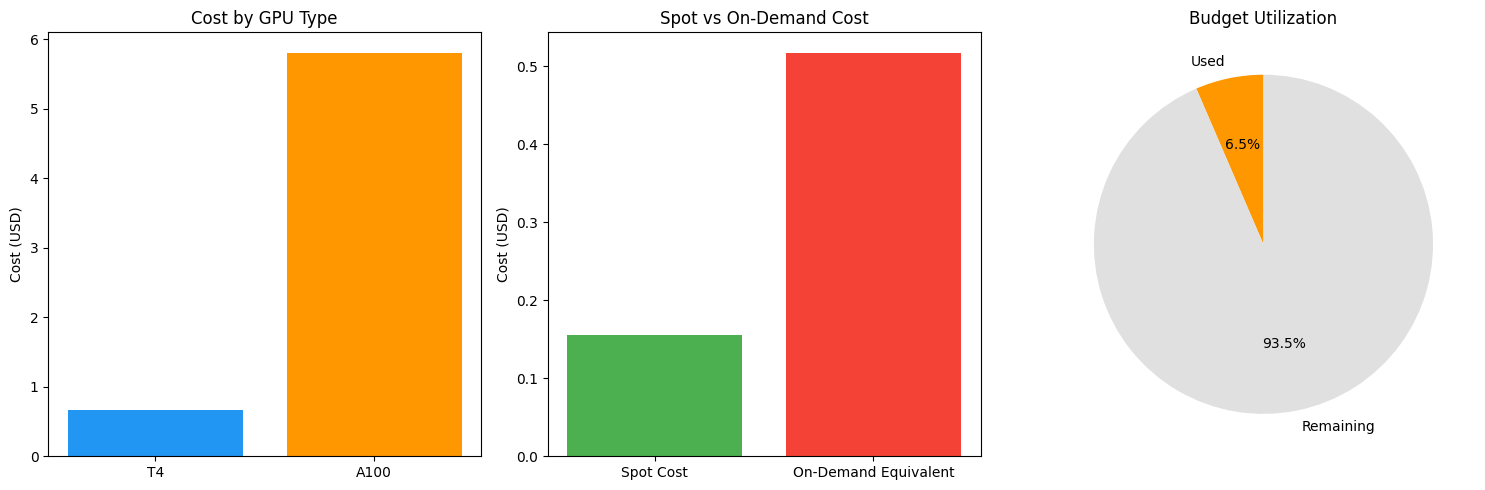

📊 Chart saved as finops_cost_breakdown.png


In [17]:
# Cell 16: Cost Breakdown Visualization
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Cost by GPU type
cost_by_type = summary.get('cost_by_gpu_type', {})
if cost_by_type:
    types = list(cost_by_type.keys())
    costs = [cost_by_type[t]['cost'] for t in types]
    axes[0].bar(types, costs, color=['#2196F3', '#FF9800', '#4CAF50'])
    axes[0].set_title('Cost by GPU Type')
    axes[0].set_ylabel('Cost (USD)')

# Chart 2: Spot vs On-Demand
spot_data = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
labels = ['Spot Cost', 'On-Demand Equivalent']
values = [spot_data.get('total_spot_cost', 0), spot_data.get('on_demand_equivalent', 0)]
axes[1].bar(labels, values, color=['#4CAF50', '#F44336'])
axes[1].set_title('Spot vs On-Demand Cost')
axes[1].set_ylabel('Cost (USD)')

# Chart 3: Budget utilization
budget_used = summary.get('budget_utilization_pct', 0)
axes[2].pie([budget_used, 100-budget_used], labels=['Used', 'Remaining'],
            colors=['#FF9800', '#E0E0E0'], autopct='%1.1f%%', startangle=90)
axes[2].set_title('Budget Utilization')

plt.tight_layout()
plt.savefig('finops_cost_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart saved as finops_cost_breakdown.png")

📈 Collecting time-series data (10 snapshots)...


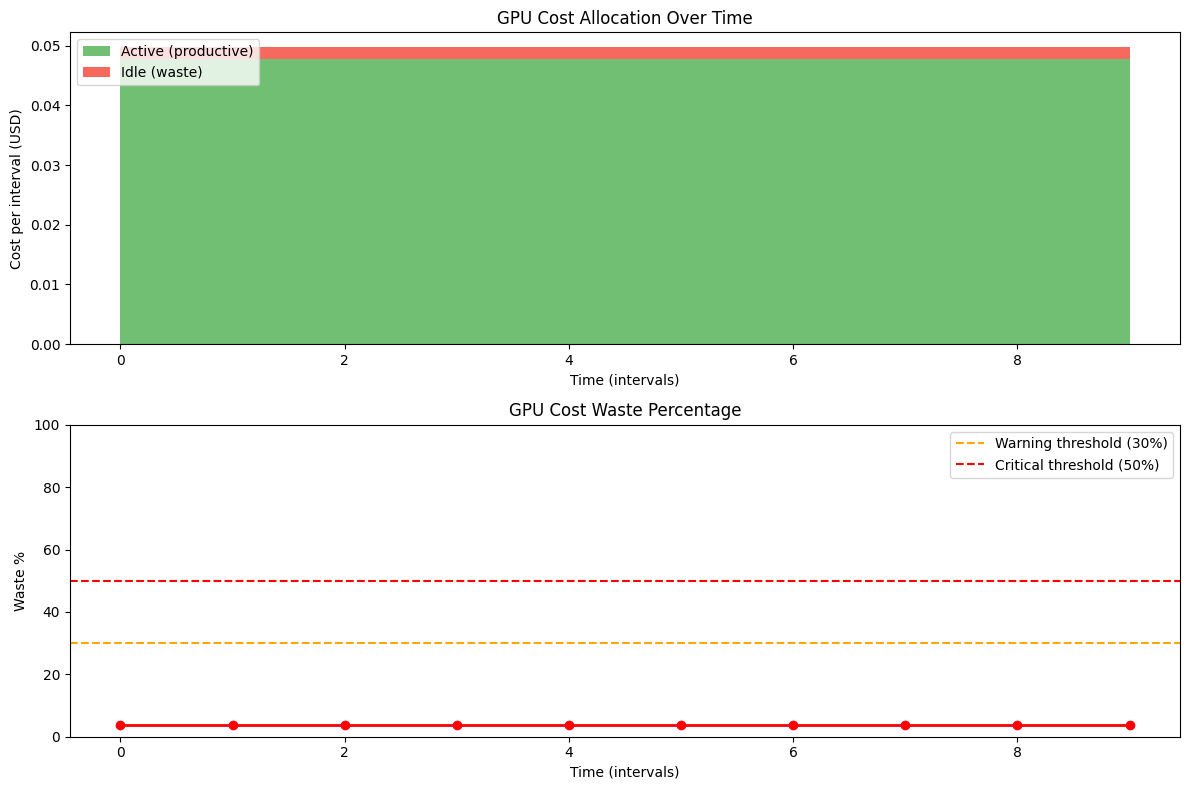

In [18]:
# Cell 17: Time-series cost tracking
print("📈 Collecting time-series data (10 snapshots)...")
ts_data = []
for i in range(10):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    ts_data.append({
        'time': i,
        'total_cost': snap['total_cost_usd'],
        'idle_cost': snap['total_idle_cost_usd'],
        'active_cost': snap['total_active_cost_usd'],
        'waste_pct': snap['waste_pct'],
    })
    time.sleep(1)

df = pd.DataFrame(ts_data)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Cost over time
ax1.stackplot(df['time'], df['active_cost'], df['idle_cost'],
              labels=['Active (productive)', 'Idle (waste)'],
              colors=['#4CAF50', '#F44336'], alpha=0.8)
ax1.set_xlabel('Time (intervals)')
ax1.set_ylabel('Cost per interval (USD)')
ax1.set_title('GPU Cost Allocation Over Time')
ax1.legend(loc='upper left')

# Waste percentage
ax2.plot(df['time'], df['waste_pct'], 'r-o', linewidth=2)
ax2.axhline(y=30, color='orange', linestyle='--', label='Warning threshold (30%)')
ax2.axhline(y=50, color='red', linestyle='--', label='Critical threshold (50%)')
ax2.set_xlabel('Time (intervals)')
ax2.set_ylabel('Waste %')
ax2.set_title('GPU Cost Waste Percentage')
ax2.legend()
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('finops_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 7: Complete FinOps Workflow
Run a full cycle: submit workloads → monitor → detect waste → autoscale → optimize cost.

In [19]:
# Cell 18: Full FinOps Optimization Workflow
print("🔄 FULL FINOPS OPTIMIZATION WORKFLOW")
print("=" * 60)

# Step 1: Check initial state
print("\n1️⃣  Initial cluster state:")
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   GPUs: {m['total_gpus']} | Util: {m['avg_utilization']:.1f}% | Idle: {m['idle_gpus']}")

# Step 2: Submit heavy workloads to increase utilization
print("\n2️⃣  Submitting heavy workloads...")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 600
    })
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   After load: Util: {m['avg_utilization']:.1f}% | Busy: {m['busy_gpus']}/{m['total_gpus']}")

# Step 3: Autoscaler evaluates
print("\n3️⃣  Autoscaler evaluation:")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
print(f"   Decision: {decision['action']} - {decision['reason']}")

# Step 4: Cost snapshot
print("\n4️⃣  Cost analysis:")
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"   Total cost/interval: ${snap['total_cost_usd']:.6f}")
print(f"   Waste: {snap['waste_pct']:.1f}%")

# Step 5: Get recommendations
print("\n5️⃣  Recommendations:")
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()
for rec in recs:
    print(f"   [{rec['priority']}] {rec['type']}: savings ~{rec['estimated_savings_pct']}%")

# Step 6: Apply optimization - use spot for some workloads
print("\n6️⃣  Applying optimization: Switch to spot instances...")
for i in range(3):
    requests.post(f"{GATEWAY_URL}/spot/request", json={
        "instance_id": f"opt-spot-{i}", "gpu_type": "T4",
        "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": f"heavy-{i:03d}"
    })

savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot savings: ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

# Step 7: Complete workloads and record billing
print("\n7️⃣  Final billing:")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/heavy-{i:03d}/complete")
    requests.post(f"{GATEWAY_URL}/billing/record", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type": "T4",
        "gpu_count": 1, "duration_seconds": 600, "is_spot": i < 3
    })

final = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total spend: ${final['total_cost_usd']:.4f}")
print(f"   Total saved: ${final['total_savings_usd']:.4f}")
print(f"   Budget: {final['budget_utilization_pct']:.1f}% used")
print(f"\n✅ Workflow complete!")

🔄 FULL FINOPS OPTIMIZATION WORKFLOW

1️⃣  Initial cluster state:
   GPUs: 20 | Util: 71.4% | Idle: 2

2️⃣  Submitting heavy workloads...
   After load: Util: 78.4% | Busy: 20/20

3️⃣  Autoscaler evaluation:
   Decision: no_action - Utilization 78.4% within thresholds [25.0-70.0%]

4️⃣  Cost analysis:
   Total cost/interval: $0.049722
   Waste: 0.0%

5️⃣  Recommendations:
   [MEDIUM] USE_SPOT: savings ~65.0%
   [LOW] SCHEDULING: savings ~20.0%

6️⃣  Applying optimization: Switch to spot instances...
   Spot savings: $0.0304 (70.0%)

7️⃣  Final billing:
   Total spend: $6.6509
   Total saved: $6.9531
   Budget: 6.7% used

✅ Workflow complete!


---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** to measure time & cost savings
4. Reports all costs back to the FinOps gateway

In [20]:
# Cell 19: Install dependencies & detect real GPU
!pip install -q torch torchvision pynvml

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
import subprocess
import threading

try:
    from pynvml import (nvmlInit, nvmlDeviceGetHandleByIndex,
                        nvmlDeviceGetUtilizationRates, nvmlDeviceGetMemoryInfo,
                        nvmlDeviceGetPowerUsage, nvmlDeviceGetTemperature)
    PYNVML_AVAILABLE = True
except ImportError:
    PYNVML_AVAILABLE = False
    print("pynvml not available, will use torch.cuda fallback for monitoring")

# Detect GPU
if not torch.cuda.is_available():
    raise RuntimeError("No GPU detected! Enable GPU in Kaggle/Colab settings.")

gpu_name = torch.cuda.get_device_name(0)
gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9

# Map real GPU to pricing
GPU_PRICING = {"T4": 0.35, "A100": 3.67, "V100": 2.48, "P100": 1.46, "L4": 0.81}
detected_type = "T4"  # default
for gtype in GPU_PRICING:
    if gtype.lower() in gpu_name.lower():
        detected_type = gtype
        break

print(f"Real GPU Detected")
print(f"   Name:    {gpu_name}")
print(f"   Memory:  {gpu_mem:.1f} GB")
print(f"   Type:    {detected_type}")
print(f"   Pricing: ${GPU_PRICING[detected_type]:.2f}/hr (on-demand)")
print(f"   CUDA:    {torch.version.cuda}")
print(f"   pynvml:  {'available' if PYNVML_AVAILABLE else 'NOT available'}")

Real GPU Detected
   Name:    Tesla T4
   Memory:  15.6 GB
   Type:    T4
   Pricing: $0.35/hr (on-demand)
   CUDA:    12.8
   pynvml:  available


In [21]:
# Cell 20: GPU Metrics Collection (works on Kaggle/Colab)
# Strategy: pynvml first (reliable Python lib), torch.cuda fallback

def get_gpu_metrics():
    """Get GPU metrics inline. Called during training loop."""

    # Method 1: pynvml (most reliable on Kaggle - pure Python, no subprocess)
    if PYNVML_AVAILABLE:
        try:
            nvmlInit()
            handle = nvmlDeviceGetHandleByIndex(0)
            util = nvmlDeviceGetUtilizationRates(handle)
            mem_info = nvmlDeviceGetMemoryInfo(handle)
            try:
                power = nvmlDeviceGetPowerUsage(handle) / 1000.0  # mW -> W
            except Exception:
                power = 0.0
            try:
                temp = nvmlDeviceGetTemperature(handle, 0)  # NVML_TEMPERATURE_GPU = 0
            except Exception:
                temp = 0.0
            return {
                'timestamp': time.time(),
                'gpu_util_pct': float(util.gpu),
                'mem_util_pct': float(util.memory),
                'mem_used_mb': mem_info.used / 1e6,
                'mem_total_mb': mem_info.total / 1e6,
                'power_watts': float(power),
                'temp_c': float(temp),
            }
        except Exception as e:
            pass  # Fall through to torch.cuda

    # Method 2: torch.cuda (always works, limited metrics)
    mem_used = torch.cuda.memory_allocated() / 1e6
    mem_reserved = torch.cuda.memory_reserved() / 1e6
    mem_total = torch.cuda.get_device_properties(0).total_memory / 1e6
    util_approx = (mem_reserved / mem_total) * 100 if mem_total > 0 else 0
    return {
        'timestamp': time.time(),
        'gpu_util_pct': util_approx,
        'mem_util_pct': util_approx,
        'mem_used_mb': mem_used,
        'mem_total_mb': mem_total,
        'power_watts': 0.0,
        'temp_c': 0.0,
    }

# === DIAGNOSTIC TEST ===
print("=" * 50)
print("GPU METRICS DIAGNOSTIC")
print("=" * 50)

# Test pynvml
print(f"\n1. pynvml available: {PYNVML_AVAILABLE}")
if PYNVML_AVAILABLE:
    try:
        nvmlInit()
        handle = nvmlDeviceGetHandleByIndex(0)
        util = nvmlDeviceGetUtilizationRates(handle)
        mem = nvmlDeviceGetMemoryInfo(handle)
        print(f"   pynvml works! GPU util={util.gpu}%, mem={mem.used/1e6:.0f}/{mem.total/1e6:.0f} MB")
        try:
            pwr = nvmlDeviceGetPowerUsage(handle) / 1000.0
            print(f"   Power: {pwr:.1f}W")
        except Exception as e:
            print(f"   Power: not available ({e})")
        try:
            tmp = nvmlDeviceGetTemperature(handle, 0)
            print(f"   Temp: {tmp}C")
        except Exception as e:
            print(f"   Temp: not available ({e})")
    except Exception as e:
        print(f"   pynvml FAILED: {e}")

# Test full function
print(f"\n2. get_gpu_metrics() test:")
test_result = get_gpu_metrics()
for k, v in sorted(test_result.items()):
    if k != 'timestamp':
        print(f"   {k}: {v}")

print(f"\n   Method: {'pynvml' if test_result.get('temp_c', 0) > 0 or (PYNVML_AVAILABLE and test_result.get('gpu_util_pct', -1) >= 0) else 'torch.cuda'}")
print(f"\nReady for training.")

GPU METRICS DIAGNOSTIC

1. pynvml available: True
   pynvml works! GPU util=0%, mem=472/16106 MB
   Power: 10.7W
   Temp: 38C

2. get_gpu_metrics() test:
   gpu_util_pct: 0.0
   mem_total_mb: 16106.12736
   mem_used_mb: 472.055808
   mem_util_pct: 0.0
   power_watts: 10.659
   temp_c: 38.0

   Method: pynvml

Ready for training.


In [22]:
# Cell 21: Prepare CIFAR-10 dataset and ResNet-18 model
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
]))
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

print(f"Dataset ready: {len(trainset)} train / {len(testset)} test images")
print(f"Batches per epoch: {len(trainloader)}")


def create_model():
    """Create a fresh ResNet-18 for CIFAR-10."""
    model = torchvision.models.resnet18(weights=None, num_classes=10)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model.cuda()


def train_epoch_monitored(model, loader, optimizer, criterion, use_amp=False, sample_interval=10):
    """Train one epoch with inline GPU metrics collection every N batches."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    scaler = GradScaler() if use_amp else None
    metrics_samples = []
    start = time.time()

    for batch_idx, (inputs, targets) in enumerate(loader):
        inputs, targets = inputs.cuda(), targets.cuda()
        optimizer.zero_grad()

        if use_amp:
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += inputs.size(0)

        # Collect GPU metrics every N batches (inline, no threading)
        if batch_idx % sample_interval == 0:
            torch.cuda.synchronize()
            sample = get_gpu_metrics()
            metrics_samples.append(sample)

    elapsed = time.time() - start
    return total_loss / total, correct / total * 100, elapsed, metrics_samples


print("Model & training functions ready (inline monitoring every 10 batches)")

100%|██████████| 170M/170M [00:02<00:00, 77.5MB/s] 


Dataset ready: 50000 train / 10000 test images
Batches per epoch: 391
Model & training functions ready (inline monitoring every 10 batches)


In [23]:
# Cell 22: Train FP32 (baseline) with inline GPU monitoring
NUM_EPOCHS = 3
price_per_hour = GPU_PRICING[detected_type]

print("=" * 60)
print("EXPERIMENT 1: FP32 Training (Baseline)")
print("=" * 60)

model_fp32 = create_model()
optimizer_fp32 = optim.SGD(model_fp32.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
fp32_start = time.time()

fp32_results = []
fp32_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_fp32, trainloader, optimizer_fp32, criterion, use_amp=False)
    fp32_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    fp32_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

fp32_total_time = time.time() - fp32_start
fp32_peak_mem = torch.cuda.max_memory_allocated() / 1e9
fp32_cost = (fp32_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(fp32_all_metrics)}")

# Build monitor dataframe
fp32_monitor_df = pd.DataFrame(fp32_all_metrics)
if not fp32_monitor_df.empty and 'timestamp' in fp32_monitor_df.columns:
    fp32_monitor_df['elapsed'] = fp32_monitor_df['timestamp'] - fp32_monitor_df['timestamp'].iloc[0]

print(f"\n   FP32 Summary:")
print(f"   Total time:      {fp32_total_time:.1f}s")
print(f"   Peak memory:     {fp32_peak_mem:.2f} GB")
if not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns:
    print(f"   Avg GPU util:    {fp32_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {fp32_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {fp32_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {fp32_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(fp32_monitor_df.columns) if not fp32_monitor_df.empty else 'EMPTY'}")
    if fp32_all_metrics:
        print(f"   First sample keys: {list(fp32_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${fp32_cost:.6f}")

EXPERIMENT 1: FP32 Training (Baseline)
   Epoch 1/3 | Loss: 2.2159 | Acc: 23.1% | Time: 39.8s | Samples: 40
   Epoch 2/3 | Loss: 1.6230 | Acc: 39.7% | Time: 40.2s | Samples: 40
   Epoch 3/3 | Loss: 1.3773 | Acc: 49.5% | Time: 42.4s | Samples: 40

   Total samples collected: 120

   FP32 Summary:
   Total time:      122.5s
   Peak memory:     0.82 GB
   Avg GPU util:    95.4%
   Avg power:       66.6W
   Avg temperature: 65.6C
   Max GPU util:    99.0%
   Estimated cost:  $0.011911


In [24]:
# Cell 23: Train Mixed Precision AMP (optimized) with inline GPU monitoring
print("=" * 60)
print("EXPERIMENT 2: Mixed Precision (AMP) Training")
print("=" * 60)

model_amp = create_model()
optimizer_amp = optim.SGD(model_amp.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
amp_start = time.time()

amp_results = []
amp_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_amp, trainloader, optimizer_amp, criterion, use_amp=True)
    amp_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    amp_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

amp_total_time = time.time() - amp_start
amp_peak_mem = torch.cuda.max_memory_allocated() / 1e9
amp_cost = (amp_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(amp_all_metrics)}")

# Build monitor dataframe
amp_monitor_df = pd.DataFrame(amp_all_metrics)
if not amp_monitor_df.empty and 'timestamp' in amp_monitor_df.columns:
    amp_monitor_df['elapsed'] = amp_monitor_df['timestamp'] - amp_monitor_df['timestamp'].iloc[0]

print(f"\n   AMP Summary:")
print(f"   Total time:      {amp_total_time:.1f}s")
print(f"   Peak memory:     {amp_peak_mem:.2f} GB")
if not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns:
    print(f"   Avg GPU util:    {amp_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {amp_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {amp_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {amp_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(amp_monitor_df.columns) if not amp_monitor_df.empty else 'EMPTY'}")
    if amp_all_metrics:
        print(f"   First sample keys: {list(amp_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${amp_cost:.6f}")

EXPERIMENT 2: Mixed Precision (AMP) Training


/tmp/ipykernel_57/927799492.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None
/tmp/ipykernel_57/927799492.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


   Epoch 1/3 | Loss: 2.1818 | Acc: 23.3% | Time: 19.9s | Samples: 40
   Epoch 2/3 | Loss: 1.5490 | Acc: 42.4% | Time: 19.3s | Samples: 40
   Epoch 3/3 | Loss: 1.2048 | Acc: 56.3% | Time: 19.3s | Samples: 40

   Total samples collected: 120

   AMP Summary:
   Total time:      58.5s
   Peak memory:     0.60 GB
   Avg GPU util:    90.7%
   Avg power:       65.6W
   Avg temperature: 77.3C
   Max GPU util:    94.0%
   Estimated cost:  $0.005684


FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)

Metric                    FP32            AMP             Improvement
----------------------------------------------------------------------
Total Time                122.5           58.5            2.10x faster
Peak Memory (GB)          0.82            0.60            0.22 GB saved
Cost (USD)                $0.011911       $0.005684       $0.006227 saved
Cost Saving %             ---             ---             52.3%
Avg GPU Util %            95.4            90.7           
Avg Power (W)             66.6            65.6           

--- Extrapolated Savings at Scale ---
   1 day training: FP32=$8.40 vs AMP=$4.01 -> SAVE $4.39
   1 week training: FP32=$58.80 vs AMP=$28.06 -> SAVE $30.74
   1 month training: FP32=$252.00 vs AMP=$120.25 -> SAVE $131.75


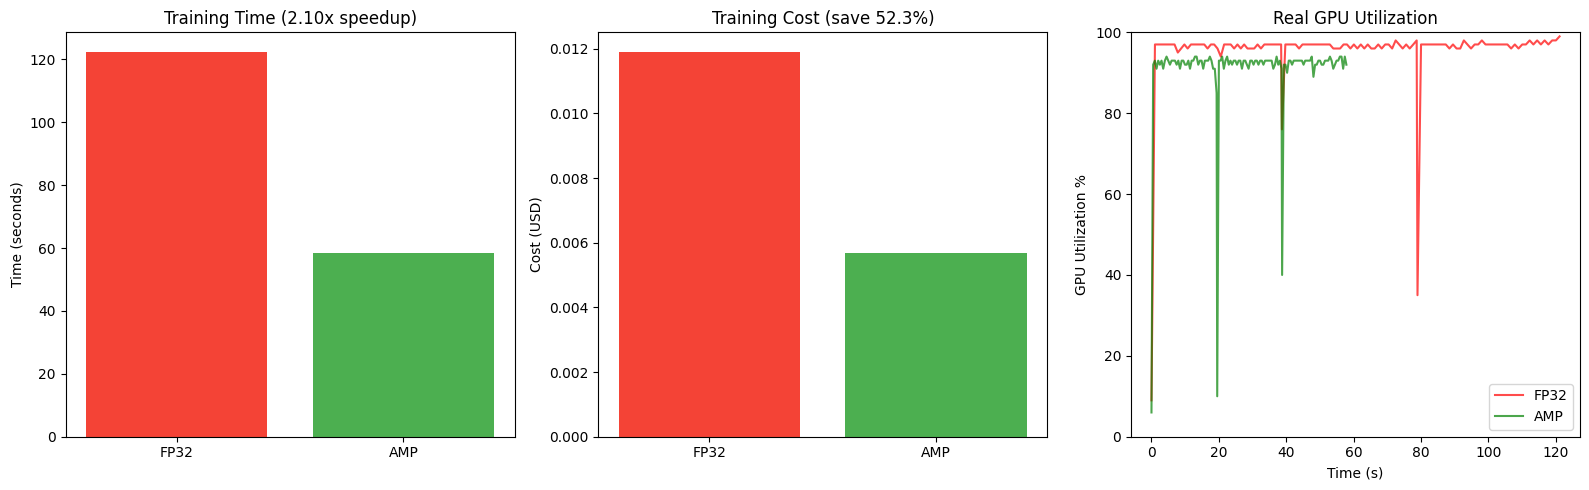

In [25]:
# Cell 24: Compare FP32 vs AMP - FinOps Analysis
print("=" * 60)
print("FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)")
print("=" * 60)

speedup = fp32_total_time / amp_total_time
cost_saving = fp32_cost - amp_cost
cost_saving_pct = (cost_saving / fp32_cost) * 100 if fp32_cost > 0 else 0
mem_saving = fp32_peak_mem - amp_peak_mem

print(f"\n{'Metric':<25} {'FP32':<15} {'AMP':<15} {'Improvement'}")
print("-" * 70)
print(f"{'Total Time':<25} {fp32_total_time:<15.1f} {amp_total_time:<15.1f} {speedup:.2f}x faster")
print(f"{'Peak Memory (GB)':<25} {fp32_peak_mem:<15.2f} {amp_peak_mem:<15.2f} {mem_saving:.2f} GB saved")
print(f"{'Cost (USD)':<25} ${fp32_cost:<14.6f} ${amp_cost:<14.6f} ${cost_saving:.6f} saved")
print(f"{'Cost Saving %':<25} {'---':<15} {'---':<15} {cost_saving_pct:.1f}%")

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    print(f"{'Avg GPU Util %':<25} {fp32_monitor_df['gpu_util_pct'].mean():<15.1f} {amp_monitor_df['gpu_util_pct'].mean():<15.1f}")
    print(f"{'Avg Power (W)':<25} {fp32_monitor_df['power_watts'].mean():<15.1f} {amp_monitor_df['power_watts'].mean():<15.1f}")

# Extrapolate to larger scale
print(f"\n--- Extrapolated Savings at Scale ---")
for scale_name, hours in [("1 day training", 24), ("1 week training", 168), ("1 month training", 720)]:
    fp32_scaled = hours * price_per_hour
    amp_scaled = (hours / speedup) * price_per_hour
    saved = fp32_scaled - amp_scaled
    print(f"   {scale_name}: FP32=${fp32_scaled:.2f} vs AMP=${amp_scaled:.2f} -> SAVE ${saved:.2f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar: Time comparison
axes[0].bar(['FP32', 'AMP'], [fp32_total_time, amp_total_time], color=['#F44336', '#4CAF50'])
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title(f'Training Time ({speedup:.2f}x speedup)')

# Bar: Cost comparison
axes[1].bar(['FP32', 'AMP'], [fp32_cost, amp_cost], color=['#F44336', '#4CAF50'])
axes[1].set_ylabel('Cost (USD)')
axes[1].set_title(f'Training Cost (save {cost_saving_pct:.1f}%)')

# Line: GPU utilization over time (both experiments) or epoch time
if has_monitor_data:
    if not fp32_monitor_df.empty:
        axes[2].plot(fp32_monitor_df['elapsed'], fp32_monitor_df['gpu_util_pct'], 'r-', alpha=0.7, label='FP32')
    if not amp_monitor_df.empty:
        axes[2].plot(amp_monitor_df['elapsed'], amp_monitor_df['gpu_util_pct'], 'g-', alpha=0.7, label='AMP')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('GPU Utilization %')
    axes[2].set_title('Real GPU Utilization')
    axes[2].legend()
    axes[2].set_ylim(0, 100)
else:
    # Fallback: show epoch times
    epochs = list(range(1, NUM_EPOCHS + 1))
    axes[2].plot(epochs, [r['time_s'] for r in fp32_results], 'r-o', label='FP32')
    axes[2].plot(epochs, [r['time_s'] for r in amp_results], 'g-o', label='AMP')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Time (s)')
    axes[2].set_title('Time per Epoch')
    axes[2].legend()

plt.tight_layout()
plt.savefig('real_gpu_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# Cell 25: Report real GPU costs back to the FinOps Gateway
print("=" * 60)
print("REPORTING REAL GPU COSTS TO FINOPS GATEWAY")
print("=" * 60)

# Report FP32 workload
fp32_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-fp32",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": fp32_total_time,
    "is_spot": False,
    "project": "real-gpu-lab",
}).json()
print(f"\n   FP32 workload reported:")
print(f"   Cost: ${fp32_report['total_cost_usd']:.6f} | Rate: ${fp32_report['rate_per_hour']:.4f}/hr")

# Report AMP workload (as spot - demonstrating cost optimization)
amp_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-amp",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": amp_total_time,
    "is_spot": True,
    "project": "real-gpu-lab",
}).json()
print(f"\n   AMP workload reported (as spot):")
print(f"   Cost: ${amp_report['total_cost_usd']:.6f} | Saved: ${amp_report['savings_usd']:.6f}")

# Submit workload info to cluster tracker
for wl_name, wl_time in [("real-gpu-resnet18-fp32", fp32_total_time), ("real-gpu-resnet18-amp", amp_total_time)]:
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": wl_name,
        "gpu_type_preferred": detected_type,
        "gpu_count": 1,
        "duration_seconds": int(wl_time),
    })

# Get updated billing summary including real GPU data
print(f"\n--- Updated FinOps Billing (incl. real GPU) ---")
summary = requests.get(f"{GATEWAY_URL}/billing/summary", params={"project": "real-gpu-lab"}).json()
print(f"   Project:         real-gpu-lab")
print(f"   Total Cost:      ${summary['total_cost_usd']:.6f}")
print(f"   Total Savings:   ${summary['total_savings_usd']:.6f}")
print(f"   Workloads:       {summary['total_workloads']}")

# Push real GPU metrics as a cost snapshot
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"\n   Cost snapshot taken: waste={snap['waste_pct']:.1f}%")

# Get final dashboard with everything
print(f"\n--- FINAL DASHBOARD (Mock + Real GPU) ---")
dash = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()
bs = dash.get('billing_summary', {})
print(f"   Total Platform Cost:  ${bs.get('total_cost_usd', 0):.4f}")
print(f"   Total Savings:        ${bs.get('total_savings_usd', 0):.4f}")
print(f"   Budget Utilization:   {bs.get('budget_utilization_pct', 0):.1f}%")
print(f"   Alert:                {bs.get('alert', 'N/A')}")

REPORTING REAL GPU COSTS TO FINOPS GATEWAY

   FP32 workload reported:
   Cost: $0.011900 | Rate: $0.3500/hr

   AMP workload reported (as spot):
   Cost: $0.001700 | Saved: $0.004000

--- Updated FinOps Billing (incl. real GPU) ---
   Project:         real-gpu-lab
   Total Cost:      $0.045300
   Total Savings:   $0.013300
   Workloads:       6

   Cost snapshot taken: waste=13.8%

--- FINAL DASHBOARD (Mock + Real GPU) ---
   Total Platform Cost:  $6.6509
   Total Savings:        $6.9531
   Budget Utilization:   6.7%
   Alert:                OK


Real GPU Telemetry During Training


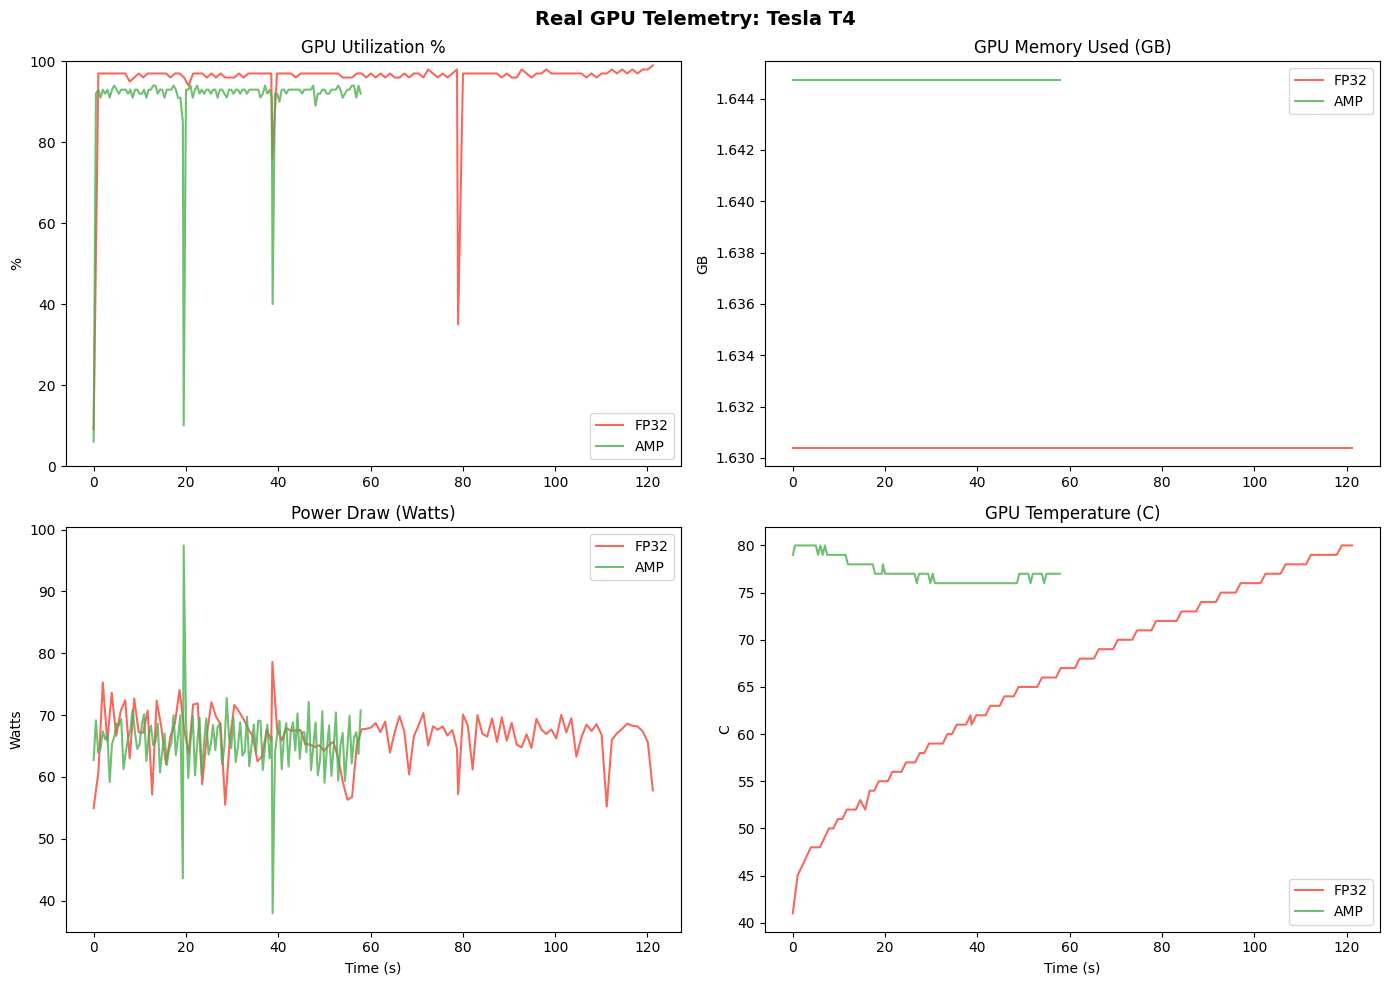

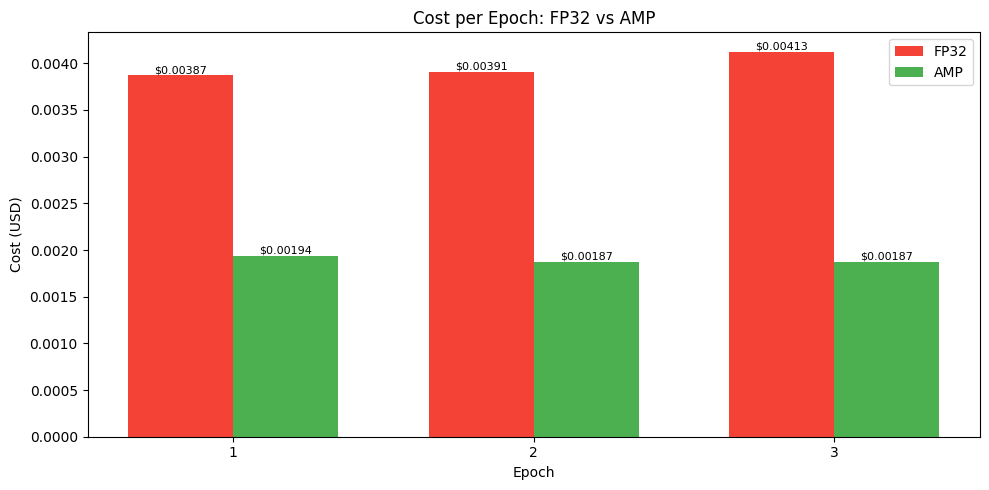


Charts saved: cost_per_epoch.png, real_gpu_telemetry.png


In [27]:
# Cell 26: Real GPU Monitoring Visualization
print("Real GPU Telemetry During Training")
print("=" * 60)

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # GPU Utilization
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 0].plot(df['elapsed'], df['gpu_util_pct'], color=color, alpha=0.8, label=label)
    axes[0, 0].set_title('GPU Utilization %')
    axes[0, 0].set_ylabel('%')
    axes[0, 0].legend()
    axes[0, 0].set_ylim(0, 100)

    # Memory Usage
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 1].plot(df['elapsed'], df['mem_used_mb'] / 1024, color=color, alpha=0.8, label=label)
    axes[0, 1].set_title('GPU Memory Used (GB)')
    axes[0, 1].set_ylabel('GB')
    axes[0, 1].legend()

    # Power Draw
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 0].plot(df['elapsed'], df['power_watts'], color=color, alpha=0.8, label=label)
    axes[1, 0].set_title('Power Draw (Watts)')
    axes[1, 0].set_ylabel('Watts')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].legend()

    # Temperature
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 1].plot(df['elapsed'], df['temp_c'], color=color, alpha=0.8, label=label)
    axes[1, 1].set_title('GPU Temperature (C)')
    axes[1, 1].set_ylabel('C')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].legend()

    plt.suptitle(f'Real GPU Telemetry: {gpu_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('real_gpu_telemetry.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("   GPU telemetry not available (monitor collected 0 samples).")
    print("   Showing epoch-level metrics instead.\n")

# Cost per epoch chart (always works)
fig, ax = plt.subplots(figsize=(10, 5))
fp32_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in fp32_results]
amp_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in amp_results]
epochs = list(range(1, NUM_EPOCHS + 1))

x = range(len(epochs))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], fp32_epoch_costs, width, label='FP32', color='#F44336')
bars2 = ax.bar([i + width/2 for i in x], amp_epoch_costs, width, label='AMP', color='#4CAF50')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cost (USD)')
ax.set_title('Cost per Epoch: FP32 vs AMP')
ax.set_xticks(x)
ax.set_xticklabels(epochs)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('cost_per_epoch.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCharts saved: cost_per_epoch.png" + (", real_gpu_telemetry.png" if has_monitor_data else ""))

---
## Part 8.5: Advanced GPU Cost Optimization
Apply advanced FinOps techniques: multi-GPU cost analysis, project forecasting, and optimization strategy prioritization.

This section extends Part 8 with:
1. **Multi-GPU Cost Analysis** - Compare scaling efficiency and determine optimal GPU count
2. **Project Cost Forecasting** - Forecast multi-phase project costs with confidence intervals
3. **Optimization Opportunity Analysis** - Prioritize and combine optimization strategies

EXERCISE 8.5.1: Multi-GPU Cost Analysis

Multi-GPU cost/performance comparison:


,gpu_count,speedup,scaling_efficiency,training_time_hours,total_gpu_hours,total_cost_usd,cost_per_speedup_usd
0,1,1.00x,100.0%,2.00,2.00,$7.34,$7.34
1,2,1.80x,90.0%,1.11,2.22,$8.16,$4.53
2,4,3.12x,78.0%,0.64,2.56,$9.41,$3.02
3,8,4.96x,62.0%,0.40,3.23,$11.84,$2.39



Optimal cost/performance point: 8x A100
   Time: 0.40h | Cost: $11.84 | Efficiency: 62.0%


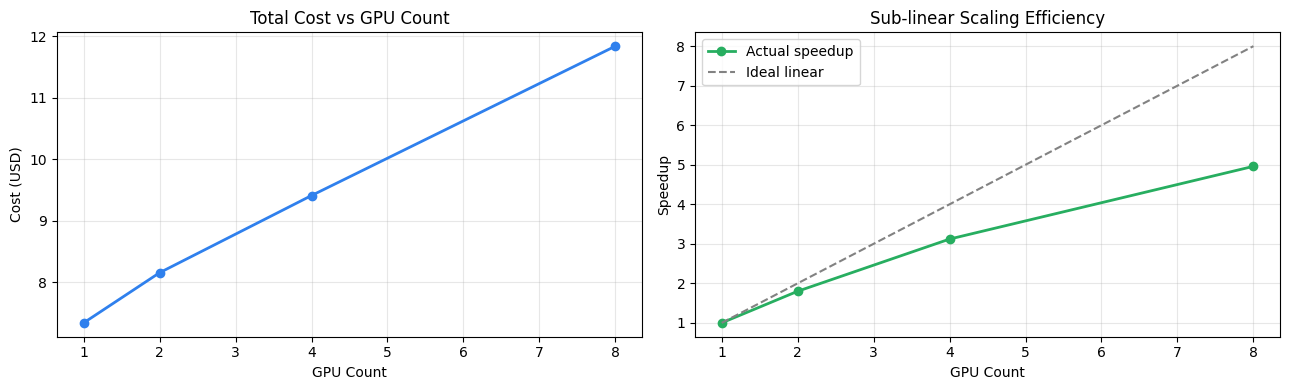


Chart saved: multi_gpu_scaling.png


In [28]:

# Cell 27: Multi-GPU Cost Analysis
print("=" * 60)
print("EXERCISE 8.5.1: Multi-GPU Cost Analysis")
print("=" * 60)


def analyze_multi_gpu_cost(base_time_hours, gpu_type, gpu_counts, scaling_factors=None):
    """Analyze total training cost across GPU counts with sub-linear scaling."""
    if gpu_type not in GPU_PRICING:
        raise ValueError(f"Unknown GPU type: {gpu_type}. Available: {list(GPU_PRICING)}")
    if base_time_hours <= 0:
        raise ValueError("base_time_hours must be positive")

    price_per_gpu_hour = GPU_PRICING[gpu_type]
    gpu_counts = sorted(set(int(c) for c in gpu_counts if int(c) > 0))

    if scaling_factors is None:
        # Realistic data-parallel scaling: communication overhead grows with GPU count.
        default_efficiency = {1: 1.00, 2: 0.90, 4: 0.78, 8: 0.62, 16: 0.45}
        scaling_factors = {
            count: count * default_efficiency.get(count, max(0.30, 1.0 - 0.12 * (count.bit_length() - 1)))
            for count in gpu_counts
        }
    else:
        scaling_factors = {int(k): float(v) for k, v in scaling_factors.items()}

    configs = []
    baseline_cost = base_time_hours * price_per_gpu_hour
    for count in gpu_counts:
        speedup = max(float(scaling_factors.get(count, count)), 0.01)
        scaling_efficiency = speedup / count
        training_time = base_time_hours / speedup
        total_gpu_hours = training_time * count
        total_cost = total_gpu_hours * price_per_gpu_hour
        cost_per_speedup = total_cost / speedup
        configs.append({
            "gpu_count": count,
            "gpu_type": gpu_type,
            "speedup": speedup,
            "scaling_efficiency": scaling_efficiency,
            "training_time_hours": training_time,
            "total_gpu_hours": total_gpu_hours,
            "total_cost_usd": total_cost,
            "cost_delta_vs_1gpu_usd": total_cost - baseline_cost,
            "cost_per_speedup_usd": cost_per_speedup,
        })

    optimal_cost = min(configs, key=lambda row: row["total_cost_usd"])
    optimal_time = min(configs, key=lambda row: row["training_time_hours"])
    optimal_balanced = min(configs, key=lambda row: row["cost_per_speedup_usd"])

    return {
        "base_time_hours": base_time_hours,
        "gpu_type": gpu_type,
        "price_per_gpu_hour": price_per_gpu_hour,
        "configs": configs,
        "optimal_cost": optimal_cost,
        "optimal_time": optimal_time,
        "optimal_balanced": optimal_balanced,
    }


base_training_time = 2.0  # hours for single GPU
test_gpu_counts = [1, 2, 4, 8]
multi_gpu_analysis = analyze_multi_gpu_cost(base_training_time, "A100", test_gpu_counts)

multi_gpu_df = pd.DataFrame(multi_gpu_analysis["configs"])
display_cols = [
    "gpu_count", "speedup", "scaling_efficiency", "training_time_hours",
    "total_gpu_hours", "total_cost_usd", "cost_per_speedup_usd",
]
print("\nMulti-GPU cost/performance comparison:")
display(multi_gpu_df[display_cols].style.format({
    "speedup": "{:.2f}x",
    "scaling_efficiency": "{:.1%}",
    "training_time_hours": "{:.2f}",
    "total_gpu_hours": "{:.2f}",
    "total_cost_usd": "${:.2f}",
    "cost_per_speedup_usd": "${:.2f}",
}))

balanced = multi_gpu_analysis["optimal_balanced"]
print(f"\nOptimal cost/performance point: {balanced['gpu_count']}x {balanced['gpu_type']}")
print(f"   Time: {balanced['training_time_hours']:.2f}h | Cost: ${balanced['total_cost_usd']:.2f} | Efficiency: {balanced['scaling_efficiency']:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(multi_gpu_df["gpu_count"], multi_gpu_df["total_cost_usd"], marker="o", linewidth=2, color="#2F80ED")
axes[0].set_title("Total Cost vs GPU Count")
axes[0].set_xlabel("GPU Count")
axes[0].set_ylabel("Cost (USD)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(multi_gpu_df["gpu_count"], multi_gpu_df["speedup"], marker="o", linewidth=2, label="Actual speedup", color="#27AE60")
axes[1].plot(multi_gpu_df["gpu_count"], multi_gpu_df["gpu_count"], linestyle="--", label="Ideal linear", color="#828282")
axes[1].set_title("Sub-linear Scaling Efficiency")
axes[1].set_xlabel("GPU Count")
axes[1].set_ylabel("Speedup")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("multi_gpu_scaling.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart saved: multi_gpu_scaling.png")


EXERCISE 8.5.2: Project Cost Forecasting

Project cost forecast by phase:


,name,gpu_type,gpu_count,duration_hours,base_cost_usd,low_cost_usd,high_cost_usd
0,Data Preparation,T4,1,40.0,$14.00,$9.88,$18.12
1,Model Training,A100,4,120.0,"$1,761.60",$898.42,"$2,624.78"
2,Hyperparameter Tuning,A100,8,60.0,"$1,761.60",$725.78,"$2,797.42"
3,Model Evaluation,T4,2,20.0,$14.00,$11.26,$16.74



Forecast summary:
   Base expected cost:        $3,551.20
   Contingency (20%):       $710.24
   Expected with buffer:      $4,261.44
   95% interval, no buffer:   $2,202.85 - $4,899.55
   95% interval, with buffer: $2,913.09 - $5,609.79


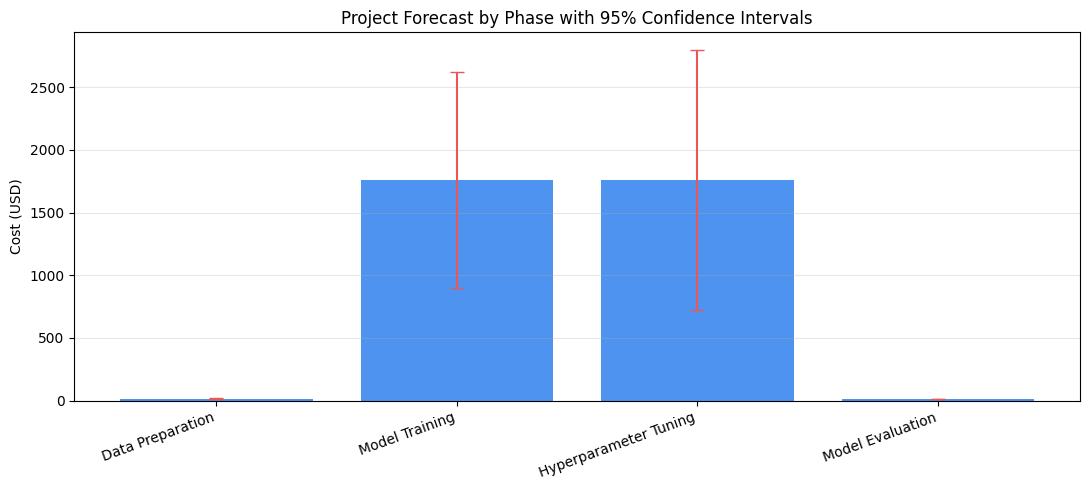


Chart saved: project_forecast.png


In [29]:

# Cell 28: Project Cost Forecasting
print("=" * 60)
print("EXERCISE 8.5.2: Project Cost Forecasting")
print("=" * 60)


def forecast_project_cost(phases, contingency_pct=20, confidence_level=0.95):
    """Forecast multi-phase GPU project cost with uncertainty intervals."""
    if not phases:
        raise ValueError("phases must not be empty")

    z_by_confidence = {0.80: 1.28, 0.90: 1.64, 0.95: 1.96, 0.99: 2.58}
    z_score = z_by_confidence.get(round(confidence_level, 2), 1.96)

    breakdown = []
    for phase in phases:
        gpu_type = phase["gpu_type"]
        if gpu_type not in GPU_PRICING:
            raise ValueError(f"Unknown GPU type in phase {phase['name']}: {gpu_type}")
        unit_rate = GPU_PRICING[gpu_type]
        base_cost = unit_rate * phase["gpu_count"] * phase["duration_hours"]
        uncertainty_pct = float(phase.get("uncertainty_pct", 0.0))
        phase_std = base_cost * uncertainty_pct
        breakdown.append({
            **phase,
            "unit_rate_usd_per_hour": unit_rate,
            "base_cost_usd": base_cost,
            "uncertainty_usd": phase_std,
            "low_cost_usd": max(0, base_cost - z_score * phase_std),
            "high_cost_usd": base_cost + z_score * phase_std,
        })

    base_total = sum(p["base_cost_usd"] for p in breakdown)
    combined_std = sum(p["uncertainty_usd"] ** 2 for p in breakdown) ** 0.5
    margin = z_score * combined_std
    contingency = base_total * (contingency_pct / 100)
    expected_with_contingency = base_total + contingency

    return {
        "confidence_level": confidence_level,
        "z_score": z_score,
        "contingency_pct": contingency_pct,
        "breakdown": breakdown,
        "base_total_usd": base_total,
        "contingency_usd": contingency,
        "expected_total_usd": expected_with_contingency,
        "confidence_interval_usd": {
            "low": max(0, base_total - margin),
            "expected": base_total,
            "high": base_total + margin,
            "low_with_contingency": max(0, expected_with_contingency - margin),
            "high_with_contingency": expected_with_contingency + margin,
        },
    }


example_project = [
    {"name": "Data Preparation", "gpu_type": "T4", "gpu_count": 1, "duration_hours": 40, "uncertainty_pct": 0.15},
    {"name": "Model Training", "gpu_type": "A100", "gpu_count": 4, "duration_hours": 120, "uncertainty_pct": 0.25},
    {"name": "Hyperparameter Tuning", "gpu_type": "A100", "gpu_count": 8, "duration_hours": 60, "uncertainty_pct": 0.30},
    {"name": "Model Evaluation", "gpu_type": "T4", "gpu_count": 2, "duration_hours": 20, "uncertainty_pct": 0.10},
]

project_forecast = forecast_project_cost(example_project, contingency_pct=20, confidence_level=0.95)
forecast_df = pd.DataFrame(project_forecast["breakdown"])

print("\nProject cost forecast by phase:")
display(forecast_df[[
    "name", "gpu_type", "gpu_count", "duration_hours", "base_cost_usd", "low_cost_usd", "high_cost_usd"
]].style.format({
    "duration_hours": "{:.1f}",
    "base_cost_usd": "${:,.2f}",
    "low_cost_usd": "${:,.2f}",
    "high_cost_usd": "${:,.2f}",
}))

ci = project_forecast["confidence_interval_usd"]
print("\nForecast summary:")
print(f"   Base expected cost:        ${project_forecast['base_total_usd']:,.2f}")
print(f"   Contingency ({project_forecast['contingency_pct']}%):       ${project_forecast['contingency_usd']:,.2f}")
print(f"   Expected with buffer:      ${project_forecast['expected_total_usd']:,.2f}")
print(f"   95% interval, no buffer:   ${ci['low']:,.2f} - ${ci['high']:,.2f}")
print(f"   95% interval, with buffer: ${ci['low_with_contingency']:,.2f} - ${ci['high_with_contingency']:,.2f}")

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(forecast_df))
phase_costs = forecast_df["base_cost_usd"].tolist()
low_errors = [c - l for c, l in zip(phase_costs, forecast_df["low_cost_usd"])]
high_errors = [h - c for c, h in zip(phase_costs, forecast_df["high_cost_usd"])]
ax.bar(x, phase_costs, color="#2F80ED", alpha=0.85)
ax.errorbar(x, phase_costs, yerr=[low_errors, high_errors], fmt="none", ecolor="#EB5757", capsize=5, linewidth=1.5)
ax.set_xticks(list(x))
ax.set_xticklabels(forecast_df["name"], rotation=20, ha="right")
ax.set_ylabel("Cost (USD)")
ax.set_title("Project Forecast by Phase with 95% Confidence Intervals")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("project_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart saved: project_forecast.png")


EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis

Baseline cost: $1,468.00

Prioritized optimization opportunities:


,name,savings_pct,estimated_savings_usd,implementation_effort,risk_level,priority_score,quick_win
0,Switch to Mixed Precision (AMP),25%,$367.00,LOW,LOW,25.0,True
1,Optimize Batch Size,15%,$220.20,LOW,LOW,15.0,True
2,Use Spot Instances,60%,$880.80,MEDIUM,HIGH,17.6,False
3,Implement Early Stopping,20%,$293.60,MEDIUM,LOW,10.0,False
4,Switch to More Efficient GPU Type,40%,$587.20,HIGH,MEDIUM,9.9,False



Implementation roadmap with compounded savings:


,step,name,incremental_savings_usd,remaining_cost_usd,cumulative_savings_pct,implementation_effort,risk_level
0,1,Switch to Mixed Precision (AMP),$367.00,"$1,101.00",25%,LOW,LOW
1,2,Optimize Batch Size,$165.15,$935.85,36%,LOW,LOW
2,3,Use Spot Instances,$561.51,$374.34,74%,MEDIUM,HIGH
3,4,Implement Early Stopping,$74.87,$299.47,80%,MEDIUM,LOW
4,5,Switch to More Efficient GPU Type,$119.79,$179.68,88%,HIGH,MEDIUM


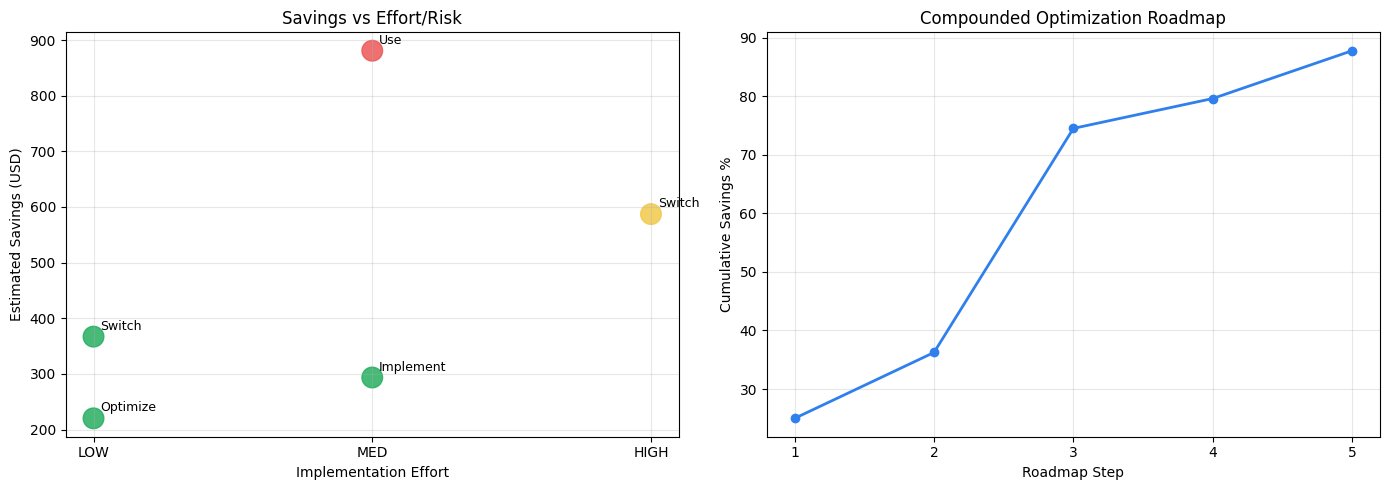


Chart saved: optimization_roadmap.png


In [30]:

# Cell 29: Optimization Opportunity Analysis
print("=" * 60)
print("EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis")
print("=" * 60)


def analyze_optimization_opportunities(current_config, optimization_strategies):
    """Prioritize optimizations by savings, effort, risk, and dependencies."""
    effort_score = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}
    risk_score = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}

    gpu_type = current_config["gpu_type"]
    baseline_cost = (
        GPU_PRICING[gpu_type]
        * current_config["gpu_count"]
        * current_config["duration_hours"]
    )

    evaluated = []
    for strategy in optimization_strategies:
        effort = effort_score[strategy["implementation_effort"]]
        risk = risk_score[strategy["risk_level"]]
        savings_usd = baseline_cost * strategy["savings_pct"]
        priority_score = (strategy["savings_pct"] * 100) / (effort * (1 + 0.35 * (risk - 1)))
        quick_win = strategy["implementation_effort"] == "LOW" and strategy["risk_level"] == "LOW"
        evaluated.append({
            **strategy,
            "baseline_cost_usd": baseline_cost,
            "estimated_savings_usd": savings_usd,
            "net_cost_after_single_strategy_usd": baseline_cost - savings_usd,
            "effort_score": effort,
            "risk_score": risk,
            "priority_score": priority_score,
            "quick_win": quick_win,
        })

    evaluated.sort(key=lambda row: (not row["quick_win"], -row["priority_score"], -row["estimated_savings_usd"]))

    remaining_cost = baseline_cost
    roadmap = []
    for step, strategy in enumerate(evaluated, start=1):
        incremental_savings = remaining_cost * strategy["savings_pct"]
        remaining_cost -= incremental_savings
        roadmap.append({
            "step": step,
            "name": strategy["name"],
            "incremental_savings_usd": incremental_savings,
            "remaining_cost_usd": remaining_cost,
            "cumulative_savings_usd": baseline_cost - remaining_cost,
            "cumulative_savings_pct": (baseline_cost - remaining_cost) / baseline_cost,
            "implementation_effort": strategy["implementation_effort"],
            "risk_level": strategy["risk_level"],
        })

    return {
        "baseline_cost_usd": baseline_cost,
        "prioritized": evaluated,
        "roadmap": roadmap,
        "final_cost_usd": remaining_cost,
        "total_savings_usd": baseline_cost - remaining_cost,
        "total_savings_pct": (baseline_cost - remaining_cost) / baseline_cost,
    }


example_strategies = [
    {"name": "Switch to Mixed Precision (AMP)", "savings_pct": 0.25, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Use Spot Instances", "savings_pct": 0.60, "implementation_effort": "MEDIUM", "risk_level": "HIGH", "dependencies": []},
    {"name": "Optimize Batch Size", "savings_pct": 0.15, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Implement Early Stopping", "savings_pct": 0.20, "implementation_effort": "MEDIUM", "risk_level": "LOW", "dependencies": []},
    {"name": "Switch to More Efficient GPU Type", "savings_pct": 0.40, "implementation_effort": "HIGH", "risk_level": "MEDIUM", "dependencies": []},
]

current_training_config = {
    "gpu_type": "A100",
    "gpu_count": 4,
    "duration_hours": 100,
    "precision": "FP32",
    "instance_type": "on-demand",
}

optimization_recommendations = analyze_optimization_opportunities(current_training_config, example_strategies)
priority_df = pd.DataFrame(optimization_recommendations["prioritized"])
roadmap_df = pd.DataFrame(optimization_recommendations["roadmap"])

print("\nBaseline cost:", f"${optimization_recommendations['baseline_cost_usd']:,.2f}")
print("\nPrioritized optimization opportunities:")
display(priority_df[[
    "name", "savings_pct", "estimated_savings_usd", "implementation_effort", "risk_level", "priority_score", "quick_win"
]].style.format({
    "savings_pct": "{:.0%}",
    "estimated_savings_usd": "${:,.2f}",
    "priority_score": "{:.1f}",
}))

print("\nImplementation roadmap with compounded savings:")
display(roadmap_df[[
    "step", "name", "incremental_savings_usd", "remaining_cost_usd", "cumulative_savings_pct", "implementation_effort", "risk_level"
]].style.format({
    "incremental_savings_usd": "${:,.2f}",
    "remaining_cost_usd": "${:,.2f}",
    "cumulative_savings_pct": "{:.0%}",
}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = priority_df["risk_level"].map({"LOW": "#27AE60", "MEDIUM": "#F2C94C", "HIGH": "#EB5757"})
axes[0].scatter(priority_df["effort_score"], priority_df["estimated_savings_usd"], s=220, c=colors, alpha=0.85)
for _, row in priority_df.iterrows():
    axes[0].annotate(row["name"].split(" ")[0], (row["effort_score"], row["estimated_savings_usd"]), xytext=(5, 5), textcoords="offset points", fontsize=9)
axes[0].set_xticks([1, 2, 3])
axes[0].set_xticklabels(["LOW", "MED", "HIGH"])
axes[0].set_xlabel("Implementation Effort")
axes[0].set_ylabel("Estimated Savings (USD)")
axes[0].set_title("Savings vs Effort/Risk")
axes[0].grid(True, alpha=0.3)

axes[1].plot(roadmap_df["step"], roadmap_df["cumulative_savings_pct"] * 100, marker="o", linewidth=2, color="#2F80ED")
axes[1].set_xticks(roadmap_df["step"])
axes[1].set_xlabel("Roadmap Step")
axes[1].set_ylabel("Cumulative Savings %")
axes[1].set_title("Compounded Optimization Roadmap")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("optimization_roadmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart saved: optimization_roadmap.png")


EXERCISE 8.5.4: Integrated Cost Dashboard


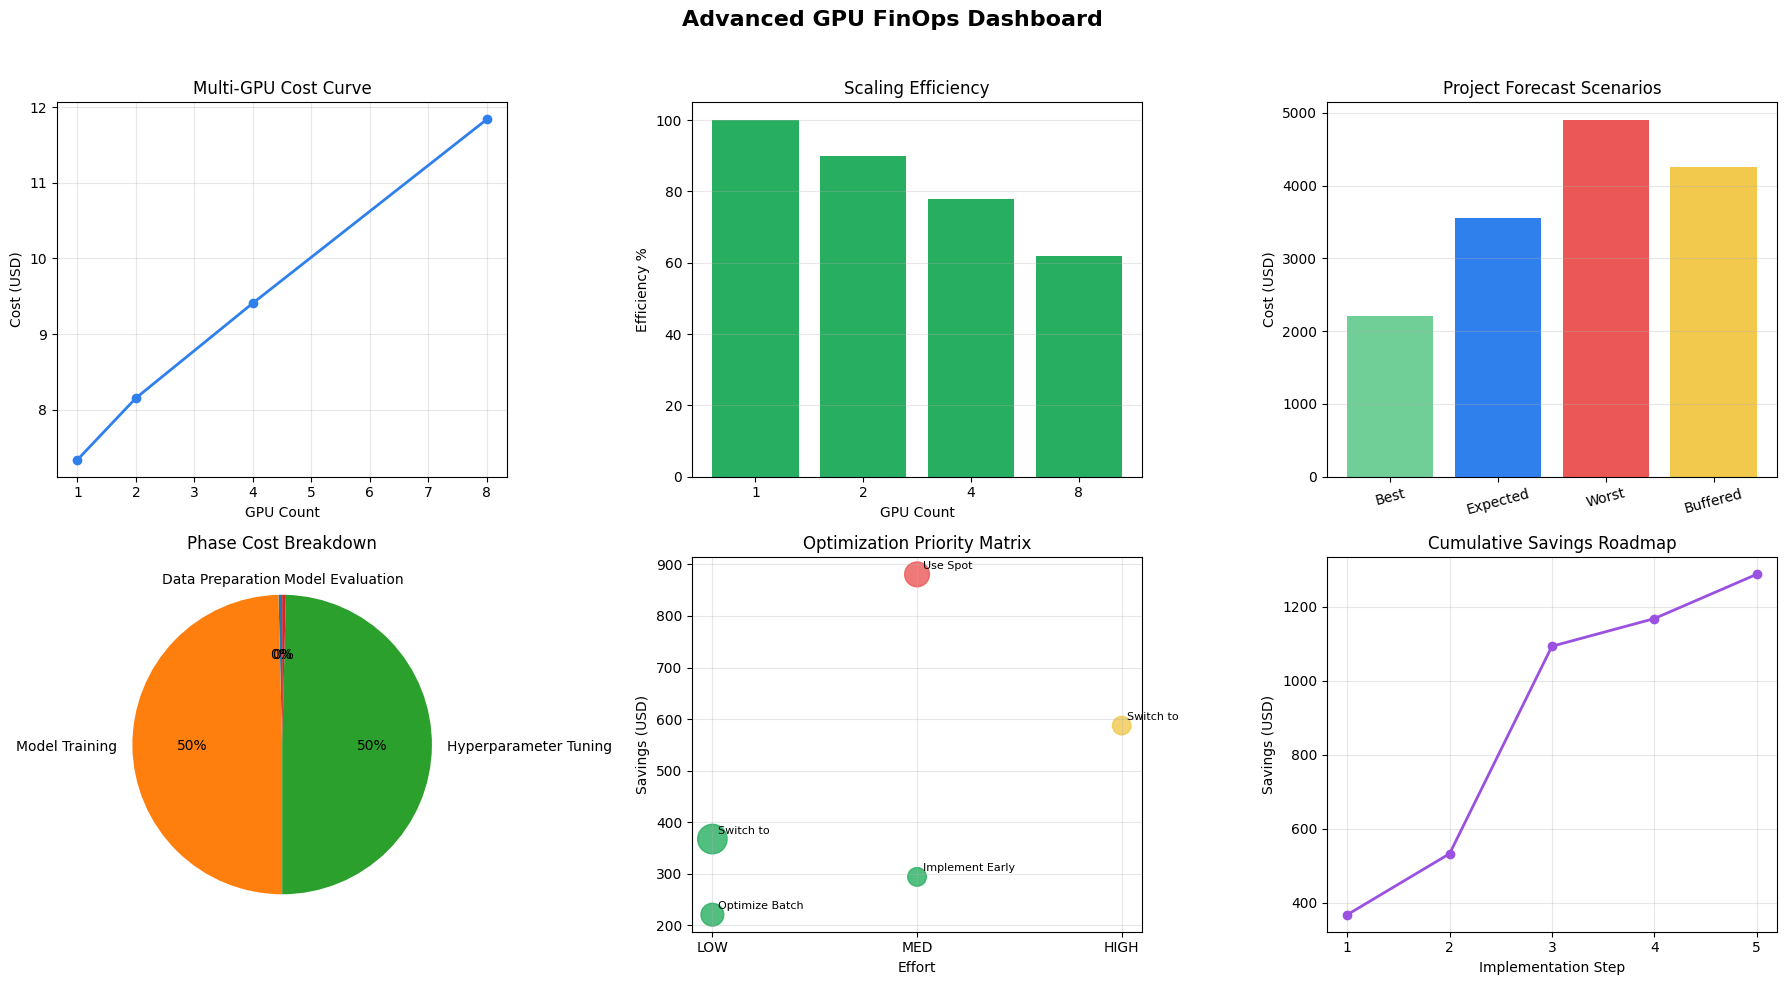


Dashboard saved: advanced_finops_dashboard.png


In [31]:

# Cell 30: Integrated Cost Dashboard
print("=" * 60)
print("EXERCISE 8.5.4: Integrated Cost Dashboard")
print("=" * 60)


def create_advanced_finops_dashboard(multi_gpu_analysis, project_forecast, optimization_recommendations):
    """Create an integrated 6-panel FinOps dashboard."""
    multi_df = pd.DataFrame(multi_gpu_analysis["configs"])
    forecast_df = pd.DataFrame(project_forecast["breakdown"])
    priority_df = pd.DataFrame(optimization_recommendations["prioritized"])
    roadmap_df = pd.DataFrame(optimization_recommendations["roadmap"])

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # 1. Multi-GPU cost curve
    axes[0, 0].plot(multi_df["gpu_count"], multi_df["total_cost_usd"], marker="o", linewidth=2, color="#2F80ED")
    axes[0, 0].set_title("Multi-GPU Cost Curve")
    axes[0, 0].set_xlabel("GPU Count")
    axes[0, 0].set_ylabel("Cost (USD)")
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Scaling efficiency
    axes[0, 1].bar(multi_df["gpu_count"].astype(str), multi_df["scaling_efficiency"] * 100, color="#27AE60")
    axes[0, 1].set_title("Scaling Efficiency")
    axes[0, 1].set_xlabel("GPU Count")
    axes[0, 1].set_ylabel("Efficiency %")
    axes[0, 1].set_ylim(0, 105)
    axes[0, 1].grid(axis="y", alpha=0.3)

    # 3. Project forecast interval
    ci = project_forecast["confidence_interval_usd"]
    scenario_names = ["Best", "Expected", "Worst", "Buffered"]
    scenario_values = [ci["low"], ci["expected"], ci["high"], project_forecast["expected_total_usd"]]
    axes[0, 2].bar(scenario_names, scenario_values, color=["#6FCF97", "#2F80ED", "#EB5757", "#F2C94C"])
    axes[0, 2].set_title("Project Forecast Scenarios")
    axes[0, 2].set_ylabel("Cost (USD)")
    axes[0, 2].tick_params(axis="x", rotation=15)
    axes[0, 2].grid(axis="y", alpha=0.3)

    # 4. Phase-by-phase breakdown
    axes[1, 0].pie(forecast_df["base_cost_usd"], labels=forecast_df["name"], autopct="%1.0f%%", startangle=90)
    axes[1, 0].set_title("Phase Cost Breakdown")

    # 5. Optimization prioritization
    risk_colors = priority_df["risk_level"].map({"LOW": "#27AE60", "MEDIUM": "#F2C94C", "HIGH": "#EB5757"})
    axes[1, 1].scatter(priority_df["effort_score"], priority_df["estimated_savings_usd"], s=priority_df["priority_score"] * 18, c=risk_colors, alpha=0.8)
    for _, row in priority_df.iterrows():
        label = " ".join(row["name"].split()[:2])
        axes[1, 1].annotate(label, (row["effort_score"], row["estimated_savings_usd"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
    axes[1, 1].set_xticks([1, 2, 3])
    axes[1, 1].set_xticklabels(["LOW", "MED", "HIGH"])
    axes[1, 1].set_title("Optimization Priority Matrix")
    axes[1, 1].set_xlabel("Effort")
    axes[1, 1].set_ylabel("Savings (USD)")
    axes[1, 1].grid(True, alpha=0.3)

    # 6. Cumulative savings roadmap
    axes[1, 2].plot(roadmap_df["step"], roadmap_df["cumulative_savings_usd"], marker="o", linewidth=2, color="#9B51E0")
    axes[1, 2].set_xticks(roadmap_df["step"])
    axes[1, 2].set_title("Cumulative Savings Roadmap")
    axes[1, 2].set_xlabel("Implementation Step")
    axes[1, 2].set_ylabel("Savings (USD)")
    axes[1, 2].grid(True, alpha=0.3)

    fig.suptitle("Advanced GPU FinOps Dashboard", fontsize=16, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    return fig


# Recompute dependencies if this cell is run independently after the functions above are defined.
if "multi_gpu_analysis" not in globals():
    multi_gpu_analysis = analyze_multi_gpu_cost(2.0, "A100", [1, 2, 4, 8])
if "project_forecast" not in globals():
    project_forecast = forecast_project_cost(example_project, contingency_pct=20, confidence_level=0.95)
if "optimization_recommendations" not in globals():
    optimization_recommendations = analyze_optimization_opportunities(current_training_config, example_strategies)

advanced_dashboard_fig = create_advanced_finops_dashboard(
    multi_gpu_analysis,
    project_forecast,
    optimization_recommendations,
)
advanced_dashboard_fig.savefig("advanced_finops_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nDashboard saved: advanced_finops_dashboard.png")


CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy
CHALLENGE SCENARIO:
   Project: Large Language Model Fine-tuning
   Baseline: 8x A100 for 200h
   Budget: $5,000
   Deadline: 2 weeks

1. Baseline cost: $5,872.00

2. Multi-GPU right-sizing result:


,gpu_count,speedup,training_time_hours,total_cost_usd,scaling_efficiency,meets_deadline
0,1,1.00x,992.0h,"$3,640.64",100%,False
1,2,1.80x,551.1h,"$4,045.16",90%,False
2,4,3.12x,317.9h,"$4,667.49",78%,True
3,8,4.96x,200.0h,"$5,872.00",62%,True


   Equivalent single-GPU work: 992.0h
   Selected: 4x A100 for 317.9h

3. Selected optimization roadmap:


,step,name,incremental_savings_usd,remaining_cost_usd,cumulative_savings_pct,risk_level
0,1,Switch to Mixed Precision (AMP),"$1,166.87","$3,500.62",25%,LOW
1,2,Optimize Batch Size and Gradient Accumulation,$525.09,"$2,975.52",36%,LOW
2,3,Use Managed Spot for Retry-safe Runs,"$1,041.43","$1,934.09",59%,MEDIUM
3,4,Implement Early Stopping and Checkpointing,$386.82,"$1,547.27",67%,LOW



4. Final strategy summary:
   Baseline cost:              $5,872.00
   Right-sized baseline:       $4,667.49
   Optimized expected cost:    $1,547.27
   Estimated total savings:    $4,324.73 (74%)
   Forecast range with buffer: $1,172.83 - $2,385.89
   Under budget:               YES
   Deadline met:               YES
   Preemption risk:            MEDIUM, controlled with checkpointing and retry-safe spot usage
   Accuracy protection:        AMP with validation gate; keep FP32 fallback if accuracy drops below 95%


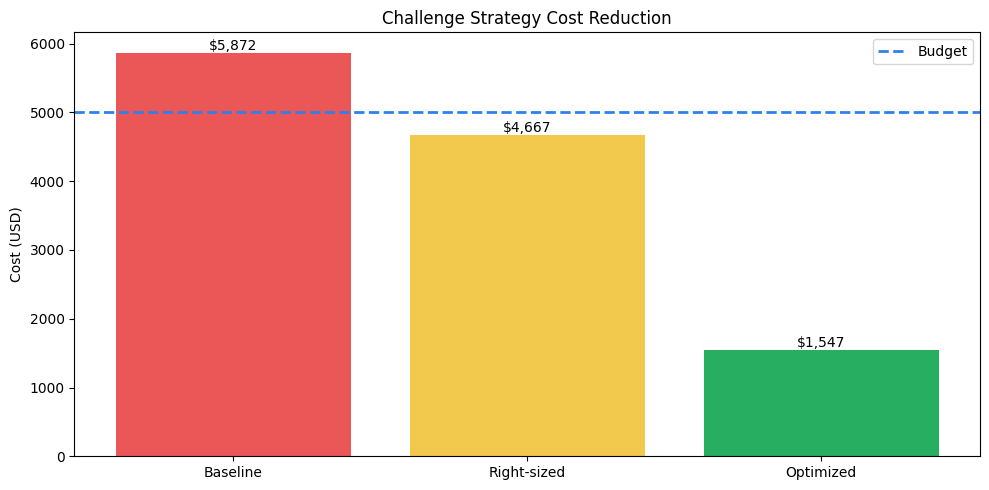


Chart saved: challenge_strategy.png


In [32]:

# Cell 31: Challenge Exercise - Cost Optimization Strategy Design
print("=" * 60)
print("CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy")
print("=" * 60)

challenge_scenario = {
    "project": "Large Language Model Fine-tuning",
    "requirements": {
        "training_duration": 200,  # hours baseline
        "gpu_type": "A100",
        "gpu_count": 8,
        "precision": "FP32",
        "instance_type": "on-demand",
        "budget": 5000,  # USD
    },
    "constraints": {
        "max_preemption_risk": "MEDIUM",
        "min_accuracy": 0.95,
        "deadline": "2 weeks",
    }
}

print("CHALLENGE SCENARIO:")
print(f"   Project: {challenge_scenario['project']}")
print(f"   Baseline: {challenge_scenario['requirements']['gpu_count']}x {challenge_scenario['requirements']['gpu_type']} for {challenge_scenario['requirements']['training_duration']}h")
print(f"   Budget: ${challenge_scenario['requirements']['budget']:,}")
print(f"   Deadline: {challenge_scenario['constraints']['deadline']}")

req = challenge_scenario["requirements"]
baseline_cost = GPU_PRICING[req["gpu_type"]] * req["gpu_count"] * req["training_duration"]
print(f"\n1. Baseline cost: ${baseline_cost:,.2f}")

# The scenario baseline is 8 GPUs for 200h. Convert that to an equivalent
# single-GPU workload using the same scaling model before right-sizing.
baseline_scaling_probe = analyze_multi_gpu_cost(
    base_time_hours=req["training_duration"],
    gpu_type=req["gpu_type"],
    gpu_counts=[1, 2, 4, 8],
)
baseline_speedup = next(
    row["speedup"]
    for row in baseline_scaling_probe["configs"]
    if row["gpu_count"] == req["gpu_count"]
)
equivalent_single_gpu_hours = req["training_duration"] * baseline_speedup

# Analyze whether fewer GPUs improve cost while still meeting the 2-week deadline.
challenge_multi_gpu = analyze_multi_gpu_cost(
    base_time_hours=equivalent_single_gpu_hours,
    gpu_type=req["gpu_type"],
    gpu_counts=[1, 2, 4, 8],
)
challenge_multi_df = pd.DataFrame(challenge_multi_gpu["configs"])
challenge_multi_df["meets_deadline"] = challenge_multi_df["training_time_hours"] <= (14 * 24)
feasible_configs = challenge_multi_df[challenge_multi_df["meets_deadline"]]
selected_config = feasible_configs.sort_values(["total_cost_usd", "training_time_hours"]).iloc[0].to_dict()

print("\n2. Multi-GPU right-sizing result:")
display(challenge_multi_df[[
    "gpu_count", "speedup", "training_time_hours", "total_cost_usd", "scaling_efficiency", "meets_deadline"
]].style.format({
    "speedup": "{:.2f}x",
    "training_time_hours": "{:.1f}h",
    "total_cost_usd": "${:,.2f}",
    "scaling_efficiency": "{:.0%}",
}))
print(f"   Equivalent single-GPU work: {equivalent_single_gpu_hours:.1f}h")
print(f"   Selected: {int(selected_config['gpu_count'])}x {req['gpu_type']} for {selected_config['training_time_hours']:.1f}h")

challenge_current_config = {
    "gpu_type": req["gpu_type"],
    "gpu_count": int(selected_config["gpu_count"]),
    "duration_hours": selected_config["training_time_hours"],
    "precision": req["precision"],
    "instance_type": req["instance_type"],
}

# Respect max_preemption_risk=MEDIUM by using managed spot only for retry-safe phases.
challenge_strategies = [
    {"name": "Switch to Mixed Precision (AMP)", "savings_pct": 0.25, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Optimize Batch Size and Gradient Accumulation", "savings_pct": 0.15, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Implement Early Stopping and Checkpointing", "savings_pct": 0.20, "implementation_effort": "MEDIUM", "risk_level": "LOW", "dependencies": []},
    {"name": "Use Managed Spot for Retry-safe Runs", "savings_pct": 0.35, "implementation_effort": "MEDIUM", "risk_level": "MEDIUM", "dependencies": ["Implement Early Stopping and Checkpointing"]},
]
challenge_optimizations = analyze_optimization_opportunities(challenge_current_config, challenge_strategies)
challenge_roadmap_df = pd.DataFrame(challenge_optimizations["roadmap"])

print("\n3. Selected optimization roadmap:")
display(challenge_roadmap_df[[
    "step", "name", "incremental_savings_usd", "remaining_cost_usd", "cumulative_savings_pct", "risk_level"
]].style.format({
    "incremental_savings_usd": "${:,.2f}",
    "remaining_cost_usd": "${:,.2f}",
    "cumulative_savings_pct": "{:.0%}",
}))

final_expected_cost = challenge_optimizations["final_cost_usd"]
challenge_forecast = forecast_project_cost([
    {
        "name": "Optimized LLM Fine-tuning",
        "gpu_type": req["gpu_type"],
        "gpu_count": int(selected_config["gpu_count"]),
        "duration_hours": selected_config["training_time_hours"],
        "uncertainty_pct": 0.20,
    }
], contingency_pct=15, confidence_level=0.95)
# Apply roadmap savings to the forecast interval as a conservative multiplier.
savings_multiplier = final_expected_cost / challenge_optimizations["baseline_cost_usd"]
ci = challenge_forecast["confidence_interval_usd"]
adjusted_low = ci["low_with_contingency"] * savings_multiplier
adjusted_high = ci["high_with_contingency"] * savings_multiplier

print("\n4. Final strategy summary:")
print(f"   Baseline cost:              ${baseline_cost:,.2f}")
print(f"   Right-sized baseline:       ${challenge_optimizations['baseline_cost_usd']:,.2f}")
print(f"   Optimized expected cost:    ${final_expected_cost:,.2f}")
print(f"   Estimated total savings:    ${baseline_cost - final_expected_cost:,.2f} ({(baseline_cost - final_expected_cost) / baseline_cost:.0%})")
print(f"   Forecast range with buffer: ${adjusted_low:,.2f} - ${adjusted_high:,.2f}")
print(f"   Under budget:               {'YES' if final_expected_cost <= req['budget'] else 'NO'}")
print(f"   Deadline met:               {'YES' if selected_config['training_time_hours'] <= 14 * 24 else 'NO'}")
print(f"   Preemption risk:            MEDIUM, controlled with checkpointing and retry-safe spot usage")
print(f"   Accuracy protection:        AMP with validation gate; keep FP32 fallback if accuracy drops below {challenge_scenario['constraints']['min_accuracy']:.0%}")

fig, ax = plt.subplots(figsize=(10, 5))
labels = ["Baseline", "Right-sized", "Optimized"]
values = [baseline_cost, challenge_optimizations["baseline_cost_usd"], final_expected_cost]
colors = ["#EB5757", "#F2C94C", "#27AE60"]
bars = ax.bar(labels, values, color=colors)
ax.axhline(req["budget"], color="#2F80ED", linestyle="--", linewidth=2, label="Budget")
ax.set_ylabel("Cost (USD)")
ax.set_title("Challenge Strategy Cost Reduction")
ax.legend()
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"${bar.get_height():,.0f}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig("challenge_strategy.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart saved: challenge_strategy.png")


---
## Summary

| Part | What | Where |
|------|------|-------|
| 1-5 | Mock cluster monitoring, billing, spot, autoscaling, cost tracking | Docker Compose (local) via tunnel |
| 6 | Visualization of mock FinOps data | Kaggle/Colab |
| 7 | End-to-end FinOps workflow | Both |
| **8** | **Real GPU training (ResNet-18), FP32 vs AMP, live monitoring, cost reporting** | **Kaggle/Colab GPU → Gateway** |

### Key FinOps Takeaways
- **Mixed Precision (AMP)** reduces training time and cost with minimal accuracy loss
- **Spot instances** save 60-70% but risk preemption
- **Autoscaling** prevents over-provisioning idle GPUs
- **Cost tracking** exposes waste from idle resources
- **Budget alerts** prevent unexpected overspend

---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** — measures time & cost savings
4. Reports all costs back to the FinOps gateway